In [1]:
# === mT5 XL: Setup + Load (bf16, HF transformers) ===
import os, gc, time
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, T5EncoderModel

PROJECT_DIR = os.path.expanduser("~/Ayesha/Dyslexia/dyslexia-mt5")
DATA_PATH = os.path.join(PROJECT_DIR, "dyslex_probe_stimuli_clean.csv")
REPS_DIR = os.path.join(PROJECT_DIR, "representations")
os.makedirs(REPS_DIR, exist_ok=True)

MODEL_NAME = "google/mt5-xl"
DEVICE = "cuda"

# Verify data present
assert os.path.exists(DATA_PATH), f"Missing CSV: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print(f"Stimuli: {len(df)} rows, {df['language'].value_counts().to_dict()}")

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print("Loading mT5 XL encoder (bf16)...")
t0 = time.time()
model = T5EncoderModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.eval()
print(f"Loaded in {time.time()-t0:.1f}s")

# Arch info
n_layers = len(model.encoder.block)
hidden = model.config.d_model
n_params = sum(p.numel() for p in model.parameters())
print(f"Encoder layers: {n_layers}  |  hidden: {hidden}  |  encoder params: {n_params/1e9:.2f}B")
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Tokenization sanity
for s in ["The cat sat on the mat.", "বিড়াল মাদুরে বসেছিল।"]:
    ids = tokenizer(s, return_tensors="pt").input_ids[0]
    print(f"'{s}' -> {len(ids)} tok, last_id={ids[-1].item()} (EOS=1)")

Stimuli: 440 rows, {'english': 220, 'bangla': 220}
Loading tokenizer...
Loading mT5 XL encoder (bf16)...


[transformers] You are using a model of type `mt5` to instantiate a model of type `t5`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/220 [00:00<?, ?it/s]

[transformers] T5EncoderModel LOAD REPORT from: google/mt5-xl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded in 6.6s
Encoder layers: 24  |  hidden: 2048  |  encoder params: 1.67B
VRAM: 3.34 GB
'The cat sat on the mat.' -> 8 tok, last_id=1 (EOS=1)
'বিড়াল মাদুরে বসেছিল।' -> 10 tok, last_id=1 (EOS=1)


In [2]:
# === mT5: extraction + sanity ===

def extract_representation(text, model, tokenizer, device="cuda"):
    """Mean-pool encoder hidden states per layer, excluding EOS."""
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512,
        add_special_tokens=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states  # tuple len = n_layers+1 (embeddings + 24)
    attention_mask = inputs["attention_mask"][0]

    # Exclude EOS (last real token). T5 has no BOS at start.
    content_mask = attention_mask.clone()
    seq_len = int(attention_mask.sum().item())
    content_mask[seq_len - 1] = 0  # zero out EOS position

    pooled_layers = []
    for layer_hidden in hidden_states:
        layer = layer_hidden[0].float()
        masked = layer * content_mask.unsqueeze(-1).float()
        denom = content_mask.sum().clamp(min=1).float()
        pooled = masked.sum(dim=0) / denom
        pooled_layers.append(pooled.cpu().numpy())
    return np.stack(pooled_layers)  # (n_layers+1, hidden)


# Sanity on 5 stimuli
sample_df = df.sample(5, random_state=42)
for _, row in sample_df.iterrows():
    reps = extract_representation(row['word'], model, tokenizer)
    print(f"[{row['language']}] '{row['word'][:30]}' -> shape {reps.shape}, "
          f"mean={reps.mean():.4f}, std={reps.std():.4f}")

print(f"\nVRAM after sanity: {torch.cuda.memory_allocated()/1e9:.2f} GB")

[bangla] 'ভালবাসা' -> shape (25, 2048), mean=0.2870, std=21.1243
[bangla] 'জাম' -> shape (25, 2048), mean=0.4673, std=19.9292
[english] 'why' -> shape (25, 2048), mean=0.2608, std=25.0506
[bangla] 'বাড়ি' -> shape (25, 2048), mean=0.0758, std=22.1604
[bangla] 'মধ্য' -> shape (25, 2048), mean=0.3212, std=24.8809

VRAM after sanity: 3.37 GB


In [3]:
# === mT5: Full extraction across 440 stimuli ===
from tqdm.auto import tqdm

all_reps = []
texts, langs, ids = [], [], []

t0 = time.time()
for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
    text = str(row['word'])
    reps = extract_representation(text, model, tokenizer)
    all_reps.append(reps)
    texts.append(text)
    langs.append(row['language'])
    ids.append(row['id'])

all_reps = np.stack(all_reps)   # (440, 25, 2048)
langs = np.array(langs)
ids = np.array(ids)
print(f"\nDone in {time.time()-t0:.1f}s")
print(f"all_reps shape: {all_reps.shape}")
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Split by language and save
en_mask = (langs == "english")
bn_mask = (langs == "bangla")

reps_en = all_reps[en_mask]   # (220, 25, 2048)
reps_bn = all_reps[bn_mask]   # (220, 25, 2048)

np.save(os.path.join(REPS_DIR, "mt5_en_reps.npy"), reps_en)
np.save(os.path.join(REPS_DIR, "mt5_bn_reps.npy"), reps_bn)
np.save(os.path.join(REPS_DIR, "mt5_ids_en.npy"), ids[en_mask])
np.save(os.path.join(REPS_DIR, "mt5_ids_bn.npy"), ids[bn_mask])

print(f"Saved: mt5_en_reps {reps_en.shape}, mt5_bn_reps {reps_bn.shape}")
print(f"NaN check: en={np.isnan(reps_en).any()}, bn={np.isnan(reps_bn).any()}")

Extracting:   0%|          | 0/440 [00:00<?, ?it/s]


Done in 4.8s
all_reps shape: (440, 25, 2048)
VRAM: 3.37 GB
Saved: mt5_en_reps (220, 25, 2048), mt5_bn_reps (220, 25, 2048)
NaN check: en=False, bn=False


In [4]:
# === RQ1: Per-layer English probing (5-fold CV) ===
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import f1_score, r2_score

df_en = df[df['language'] == 'english'].reset_index(drop=True)
assert len(df_en) == reps_en.shape[0], "Row count mismatch EN"

N_LAYERS = reps_en.shape[1]   # 25 = embeddings + 24

def build_task_masks_labels(df_lang):
    """Return dict task -> (mask, y) for valid rows."""
    tasks = {}

    # voicing: binary voiced vs unvoiced
    m = df_lang['voiced_unvoiced'].isin(['voiced','unvoiced']).values
    y = (df_lang.loc[m, 'voiced_unvoiced'] == 'voiced').astype(int).values
    tasks['voicing'] = (m, y, 'binary')

    # realword: binary real vs pseudo
    m = df_lang['is_real_word'].isin([True, False, 'True', 'False', 'true','false', 1, 0]).values
    yvals = df_lang.loc[m, 'is_real_word']
    y = yvals.astype(str).str.lower().isin(['true','1']).astype(int).values
    tasks['realword'] = (m, y, 'binary')

    # ortho: binary transparent vs opaque
    m = df_lang['orthographic_transparency'].isin(['transparent','opaque']).values
    y = (df_lang.loc[m, 'orthographic_transparency'] == 'transparent').astype(int).values
    tasks['ortho'] = (m, y, 'binary')

    # syllable: regression
    m = df_lang['syllable_count'].notna().values
    y = df_lang.loc[m, 'syllable_count'].astype(float).values
    tasks['syllable'] = (m, y, 'regression')

    return tasks

tasks_en = build_task_masks_labels(df_en)
for tname, (m, y, kind) in tasks_en.items():
    print(f"{tname:10s}: n={m.sum():3d}  kind={kind}  "
          + (f"pos={y.sum()}/{len(y)}" if kind=='binary' else f"range={y.min():.0f}-{y.max():.0f}"))

def cv_score(X, y, kind, n_splits=5):
    if kind == 'binary':
        if len(np.unique(y)) < 2 or min(np.bincount(y)) < n_splits:
            return np.nan
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, te in splitter.split(X, y):
            clf = make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
            clf.fit(X[tr], y[tr])
            scores.append(f1_score(y[te], clf.predict(X[te]), average='macro'))
        return float(np.mean(scores))
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, te in splitter.split(X):
            reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            reg.fit(X[tr], y[tr])
            scores.append(r2_score(y[te], reg.predict(X[te])))
        return float(np.mean(scores))

rows = []
for tname, (m, y, kind) in tasks_en.items():
    for L in range(N_LAYERS):
        X = reps_en[m, L, :]
        s = cv_score(X, y, kind)
        rows.append({'task': tname, 'layer': L, 'kind': kind, 'score': s})

res_en = pd.DataFrame(rows)
res_en.to_csv(os.path.join(PROJECT_DIR, "results_english_probing_mt5.csv"), index=False)

# Peak per task
print("\nRQ1 peaks (mT5 EN):")
for t in ['voicing','realword','ortho','syllable']:
    sub = res_en[res_en.task==t].dropna()
    if len(sub):
        peak = sub.loc[sub.score.idxmax()]
        print(f"  {t:10s}: L{int(peak.layer):>2d} / {peak.score:.3f}")

voicing   : n= 30  kind=binary  pos=15/30
realword  : n=220  kind=binary  pos=195/220
ortho     : n=220  kind=binary  pos=182/220
syllable  : n=220  kind=regression  range=1-8

RQ1 peaks (mT5 EN):
  voicing   : L 9 / 0.583
  realword  : L24 / 0.810
  ortho     : L21 / 0.687
  syllable  : L20 / 0.764


In [5]:
# === RQ2: Cross-lingual transfer EN -> BN (frozen probe) ===
df_bn = df[df['language'] == 'bangla'].reset_index(drop=True)
assert len(df_bn) == reps_bn.shape[0]

# Bangla voicing label fix (from README)
voiced_starters   = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}
def infer_bn_voicing(row):
    if row.get('error_type_targeted') not in ('voiced_unvoiced_confusion','aspiration_confusion'):
        return row.get('voiced_unvoiced')
    fc = str(row['word'])[0] if str(row['word']) else ''
    if fc in voiced_starters:   return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'

df_bn = df_bn.copy()
df_bn['voiced_unvoiced'] = df_bn.apply(infer_bn_voicing, axis=1)

tasks_bn = build_task_masks_labels(df_bn)
for tname, (m, y, kind) in tasks_bn.items():
    print(f"BN {tname:10s}: n={m.sum():3d}  "
          + (f"pos={y.sum()}/{len(y)}" if kind=='binary' else f"range={y.min():.0f}-{y.max():.0f}"))

def transfer_score(X_tr, y_tr, X_te, y_te, kind):
    """Train probe on ALL English data, evaluate on Bangla."""
    if kind == 'binary':
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            return np.nan
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
        clf.fit(X_tr, y_tr)
        return float(f1_score(y_te, clf.predict(X_te), average='macro'))
    else:
        reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        reg.fit(X_tr, y_tr)
        return float(r2_score(y_te, reg.predict(X_te)))

rows = []
for tname in ['voicing','realword','ortho','syllable']:
    m_en, y_en, kind = tasks_en[tname]
    m_bn, y_bn, _    = tasks_bn[tname]
    if m_bn.sum() == 0:
        continue
    for L in range(N_LAYERS):
        X_en = reps_en[m_en, L, :]
        X_bn = reps_bn[m_bn, L, :]
        s = transfer_score(X_en, y_en, X_bn, y_bn, kind)
        rows.append({'task': tname, 'layer': L, 'kind': kind, 'bn_score': s})

res_tr = pd.DataFrame(rows)
res_tr.to_csv(os.path.join(PROJECT_DIR, "results_transfer_mt5.csv"), index=False)

# Best layer per task + transfer ratio
print("\nRQ2 EN->BN (mT5):")
print(f"{'task':10s} {'best_L':>6s} {'BN':>6s} {'EN_peak':>8s} {'ratio':>6s}")
for t in ['voicing','realword','ortho','syllable']:
    sub = res_tr[res_tr.task==t].dropna()
    if len(sub) == 0: continue
    best = sub.loc[sub.bn_score.idxmax()]
    en_peak = res_en[res_en.task==t].score.max()
    ratio = best.bn_score / en_peak if en_peak > 0 else np.nan
    print(f"{t:10s} {int(best.layer):>6d} {best.bn_score:>6.3f} {en_peak:>8.3f} {ratio:>6.3f}")

BN voicing   : n= 46  pos=23/46
BN realword  : n=220  pos=195/220
BN ortho     : n=220  pos=184/220
BN syllable  : n=220  range=1-7

RQ2 EN->BN (mT5):
task       best_L     BN  EN_peak  ratio
voicing        15  0.673    0.583  1.154
realword       17  0.667    0.810  0.823
ortho          16  0.603    0.687  0.878
syllable       20  0.568    0.764  0.743


In [6]:
# === RSA: cross-lingual representational similarity (fixed cat name) ===
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

df_concepts = df[df['task_category'] == 'concept_match'].copy()
print(f"Concept rows: {len(df_concepts)}")

pair_ids_sorted = sorted(df_concepts['matched_pair_id'].dropna().unique())
en_idx, bn_idx = [], []
for pid in pair_ids_sorted:
    sub = df_concepts[df_concepts['matched_pair_id'] == pid]
    en_rows = sub[sub['language'] == 'english']
    bn_rows = sub[sub['language'] == 'bangla']
    if len(en_rows) == 1 and len(bn_rows) == 1:
        en_id = en_rows.iloc[0]['id']
        bn_id = bn_rows.iloc[0]['id']
        en_pos = np.where(ids[en_mask] == en_id)[0]
        bn_pos = np.where(ids[bn_mask] == bn_id)[0]
        if len(en_pos) and len(bn_pos):
            en_idx.append(int(en_pos[0]))
            bn_idx.append(int(bn_pos[0]))

en_idx = np.array(en_idx, dtype=int)
bn_idx = np.array(bn_idx, dtype=int)
n_pairs = len(en_idx)
print(f"Aligned pairs: {n_pairs}")
assert n_pairs >= 5, "Too few pairs for RSA"

rsa_rows = []
for L in range(N_LAYERS):
    Xe = reps_en[en_idx, L, :]
    Xb = reps_bn[bn_idx, L, :]

    rdm_e = pdist(Xe, metric='cosine')
    rdm_b = pdist(Xb, metric='cosine')
    rho, _ = spearmanr(rdm_e, rdm_b)

    Xe_n = Xe / (np.linalg.norm(Xe, axis=1, keepdims=True) + 1e-9)
    Xb_n = Xb / (np.linalg.norm(Xb, axis=1, keepdims=True) + 1e-9)
    sim = Xe_n @ Xb_n.T
    pred = sim.argmax(axis=1)
    top1 = float((pred == np.arange(n_pairs)).mean())

    rsa_rows.append({'layer': L, 'rdm_spearman': rho, 'top1_en2bn': top1})

res_rsa = pd.DataFrame(rsa_rows)
res_rsa.to_csv(os.path.join(PROJECT_DIR, "results_rsa_mt5.csv"), index=False)

peak_rdm  = res_rsa.loc[res_rsa.rdm_spearman.idxmax()]
peak_top1 = res_rsa.loc[res_rsa.top1_en2bn.idxmax()]
print(f"\nRSA peaks (mT5, n_pairs={n_pairs}):")
print(f"  RDM Spearman: L{int(peak_rdm.layer):>2d} / {peak_rdm.rdm_spearman:.3f}")
print(f"  Top-1 EN->BN: L{int(peak_top1.layer):>2d} / {peak_top1.top1_en2bn:.3f}")
print(f"\nLayer snapshot:")
snap = res_rsa.iloc[[0, 6, 12, 18, 21, 24]]
print(snap.to_string(index=False))

Concept rows: 40
Aligned pairs: 20

RSA peaks (mT5, n_pairs=20):
  RDM Spearman: L15 / 0.244
  Top-1 EN->BN: L 0 / 0.500

Layer snapshot:
 layer  rdm_spearman  top1_en2bn
     0      0.027789        0.50
     6      0.141550        0.40
    12      0.115118        0.45
    18      0.046847        0.25
    21     -0.123398        0.25
    24     -0.032648        0.05


In [7]:
# === RQ3 prep: train frozen probes, rank units per task ===
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Per-task config: ablate block + measure layer (peak from res_en).
# Rule: measure_layer = EN peak (index into pooled reps, 0=embeddings, k=output of block k-1)
#       ablate_block_idx = measure_layer - 3  -> 2 blocks of propagation
TASKS = {
    "voicing":  {"measure_L":  9, "ablate_block":  6, "kind": "binary"},
    "realword": {"measure_L": 24, "ablate_block": 21, "kind": "binary"},
    "ortho":    {"measure_L": 21, "ablate_block": 18, "kind": "binary"},
    "syllable": {"measure_L": 20, "ablate_block": 17, "kind": "regression"},
}

# Train frozen probe on baseline EN at measure_L, rank units by |coef|
frozen_probes = {}     # task -> fitted pipeline
ranked_units  = {}     # task -> array of unit indices sorted by |coef| desc

for tname, cfg in TASKS.items():
    m_en, y_en, kind = tasks_en[tname]
    X = reps_en[m_en, cfg["measure_L"], :]
    if kind == "binary":
        pipe = make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
    else:
        pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    pipe.fit(X, y_en)
    frozen_probes[tname] = pipe

    coef = pipe.named_steps['logisticregression'].coef_[0] if kind == "binary" \
           else pipe.named_steps['ridge'].coef_
    order = np.argsort(np.abs(coef))[::-1].copy()
    ranked_units[tname] = order
    print(f"{tname:10s} measure_L={cfg['measure_L']:>2d}  ablate_block={cfg['ablate_block']:>2d}  "
          f"top5_units={order[:5].tolist()}")

np.save(os.path.join(REPS_DIR, "mt5_task_ranked_units.npy"),
        {t: u for t, u in ranked_units.items()}, allow_pickle=True)
print("\nSaved ranked units.")

voicing    measure_L= 9  ablate_block= 6  top5_units=[1380, 2028, 1718, 609, 181]
realword   measure_L=24  ablate_block=21  top5_units=[21, 1832, 1195, 1515, 1643]
ortho      measure_L=21  ablate_block=18  top5_units=[1824, 1948, 138, 1961, 1269]
syllable   measure_L=20  ablate_block=17  top5_units=[1888, 748, 1747, 807, 1957]

Saved ranked units.


In [8]:
# === RQ3: Ablation hook + per-task evaluation ===
from sklearn.metrics import f1_score, r2_score

def extract_with_ablation(text, model, tokenizer, ablate_block, ablate_units, device="cuda"):
    units_t = torch.tensor(ablate_units, dtype=torch.long, device=device)
    def hook_fn(module, inp, output):
        if isinstance(output, tuple):
            h = output[0].clone()
            h[:, :, units_t] = 0.0
            return (h,) + output[1:]
        h = output.clone()
        h[:, :, units_t] = 0.0
        return h
    handle = model.encoder.block[ablate_block].register_forward_hook(hook_fn)
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True,
                           max_length=512, add_special_tokens=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"][0]
        content_mask = attention_mask.clone()
        seq_len = int(attention_mask.sum().item())
        content_mask[seq_len - 1] = 0
        pooled_layers = []
        for layer_hidden in hidden_states:
            layer = layer_hidden[0].float()
            masked = layer * content_mask.unsqueeze(-1).float()
            denom = content_mask.sum().clamp(min=1).float()
            pooled = masked.sum(dim=0) / denom
            pooled_layers.append(pooled.cpu().numpy())
        return np.stack(pooled_layers)
    finally:
        handle.remove()

def score_frozen(pipe, X, y, kind):
    if kind == "binary":
        return float(f1_score(y, pipe.predict(X), average='macro'))
    else:
        return float(r2_score(y, pipe.predict(X)))

# Conditions per task
def get_conditions(ranked, hidden_size=2048, seed=0):
    rng = np.random.default_rng(seed)
    rand10 = rng.choice(hidden_size, size=10, replace=False)
    return {
        "top5":   ranked[:5].tolist(),
        "top10":  ranked[:10].tolist(),
        "top20":  ranked[:20].tolist(),
        "rand10": rand10.tolist(),
    }

# Baseline scores (frozen probe applied to existing baseline reps)
print("=== Baseline (no ablation) ===")
baseline_scores = {}
for tname, cfg in TASKS.items():
    m_en, y_en, kind = tasks_en[tname]
    m_bn, y_bn, _    = tasks_bn[tname]
    pipe = frozen_probes[tname]
    X_en = reps_en[m_en, cfg["measure_L"], :]
    X_bn = reps_bn[m_bn, cfg["measure_L"], :]
    s_en = score_frozen(pipe, X_en, y_en, kind)
    s_bn = score_frozen(pipe, X_bn, y_bn, kind)
    baseline_scores[tname] = (s_en, s_bn)
    print(f"  {tname:10s} EN={s_en:.3f}  BN={s_bn:.3f}")

# Ablation loop
print("\n=== Ablation conditions ===")
df_en_full = df[df['language']=='english'].reset_index(drop=True)
df_bn_full = df[df['language']=='bangla' ].reset_index(drop=True)
df_bn_full = df_bn_full.copy()
df_bn_full['voiced_unvoiced'] = df_bn_full.apply(infer_bn_voicing, axis=1)

ablation_rows = []
t0 = time.time()
for tname, cfg in TASKS.items():
    m_en, y_en, kind = tasks_en[tname]
    m_bn, y_bn, _    = tasks_bn[tname]
    pipe = frozen_probes[tname]
    conds = get_conditions(ranked_units[tname], hidden_size=2048, seed=42)

    en_texts = df_en_full.loc[m_en, 'word'].astype(str).tolist()
    bn_texts = df_bn_full.loc[m_bn, 'word'].astype(str).tolist()

    for cond_name, units in conds.items():
        # EN reps under ablation
        en_reps_abl = np.stack([
            extract_with_ablation(t, model, tokenizer, cfg["ablate_block"], units)
            for t in en_texts
        ])
        # BN reps under ablation
        bn_reps_abl = np.stack([
            extract_with_ablation(t, model, tokenizer, cfg["ablate_block"], units)
            for t in bn_texts
        ])

        X_en = en_reps_abl[:, cfg["measure_L"], :]
        X_bn = bn_reps_abl[:, cfg["measure_L"], :]
        s_en = score_frozen(pipe, X_en, y_en, kind)
        s_bn = score_frozen(pipe, X_bn, y_bn, kind)

        b_en, b_bn = baseline_scores[tname]
        ablation_rows.append({
            "task": tname, "condition": cond_name, "n_units": len(units),
            "ablate_block": cfg["ablate_block"], "measure_L": cfg["measure_L"],
            "score_en": s_en, "score_bn": s_bn,
            "drop_en": b_en - s_en, "drop_bn": b_bn - s_bn,
        })
        print(f"  {tname:10s} {cond_name:6s}  EN={s_en:.3f} (Δ{b_en-s_en:+.3f})  "
              f"BN={s_bn:.3f} (Δ{b_bn-s_bn:+.3f})")

        # Save the reps
        np.save(os.path.join(REPS_DIR, f"mt5_{tname}_ablate_{cond_name}_en.npy"), en_reps_abl)
        np.save(os.path.join(REPS_DIR, f"mt5_{tname}_ablate_{cond_name}_bn.npy"), bn_reps_abl)

print(f"\nDone in {time.time()-t0:.1f}s")

res_abl = pd.DataFrame(ablation_rows)
# Tag baseline rows
base_rows = [{"task": t, "condition": "baseline", "n_units": 0,
              "ablate_block": -1, "measure_L": TASKS[t]["measure_L"],
              "score_en": baseline_scores[t][0], "score_bn": baseline_scores[t][1],
              "drop_en": 0.0, "drop_bn": 0.0} for t in TASKS]
res_abl = pd.concat([pd.DataFrame(base_rows), res_abl], ignore_index=True)
res_abl.to_csv(os.path.join(PROJECT_DIR, "results_ablation_mt5_final.csv"), index=False)

print("\n=== Summary ===")
print(res_abl.to_string(index=False))

=== Baseline (no ablation) ===
  voicing    EN=1.000  BN=0.538
  realword   EN=1.000  BN=0.436
  ortho      EN=0.992  BN=0.574
  syllable   EN=1.000  BN=0.568

=== Ablation conditions ===
  voicing    top5    EN=1.000 (Δ+0.000)  BN=0.538 (Δ+0.000)
  voicing    top10   EN=1.000 (Δ+0.000)  BN=0.538 (Δ+0.000)
  voicing    top20   EN=1.000 (Δ+0.000)  BN=0.502 (Δ+0.036)
  voicing    rand10  EN=1.000 (Δ+0.000)  BN=0.538 (Δ+0.000)
  realword   top5    EN=1.000 (Δ+0.000)  BN=0.429 (Δ+0.007)
  realword   top10   EN=1.000 (Δ+0.000)  BN=0.429 (Δ+0.007)
  realword   top20   EN=1.000 (Δ+0.000)  BN=0.436 (Δ+0.000)
  realword   rand10  EN=1.000 (Δ+0.000)  BN=0.457 (Δ-0.021)
  ortho      top5    EN=0.992 (Δ+0.000)  BN=0.567 (Δ+0.007)
  ortho      top10   EN=0.992 (Δ+0.000)  BN=0.556 (Δ+0.018)
  ortho      top20   EN=0.992 (Δ+0.000)  BN=0.524 (Δ+0.050)
  ortho      rand10  EN=0.992 (Δ+0.000)  BN=0.549 (Δ+0.025)
  syllable   top5    EN=0.998 (Δ+0.002)  BN=0.565 (Δ+0.003)
  syllable   top10   EN=0.996 (Δ

In [9]:
# === Load 4-model results ===
BASE = os.path.expanduser("~/Ayesha/Dyslexia")

PATHS = {
    "xlmr": {
        "dir": f"{BASE}/Dyslexia-XLM-R",
        "english": "results_english_probing.csv",
        "transfer": "results_transfer.csv",
        "rsa":      "results_rsa.csv",
        "ablation": "results_ablation.csv",
    },
    "llama": {
        "dir": f"{BASE}/dyslexia-LLM",
        "english": "results_english_probing_llama.csv",
        "transfer": "results_transfer_llama.csv",
        "rsa":      "results_rsa_llama.csv",
        "ablation": "results_ablation_llama_final.csv",
    },
    "bloom": {
        "dir": f"{BASE}/dyslexia-bloom",
        "english": "results_english_probing_bloom.csv",
        "transfer": "results_transfer_bloom.csv",
        "rsa":      "results_rsa_bloom.csv",
        "ablation": "results_ablation_bloom_final.csv",
    },
    "mt5": {
        "dir": f"{BASE}/dyslexia-mt5",
        "english": "results_english_probing_mt5.csv",
        "transfer": "results_transfer_mt5.csv",
        "rsa":      "results_rsa_mt5.csv",
        "ablation": "results_ablation_mt5_final.csv",
    },
}

results = {}
for m, p in PATHS.items():
    results[m] = {}
    for k in ["english","transfer","rsa","ablation"]:
        fp = os.path.join(p["dir"], p[k])
        if os.path.exists(fp):
            results[m][k] = pd.read_csv(fp)
            print(f"  ✅ {m:6s} {k:10s} -> {results[m][k].shape}")
        else:
            results[m][k] = None
            print(f"  ❌ {m:6s} {k:10s} MISSING ({fp})")

# Show columns for sanity (schemas may differ across folders)
print("\nColumn schemas:")
for m in results:
    for k, dfk in results[m].items():
        if dfk is not None:
            print(f"  {m:6s} {k:10s}: {list(dfk.columns)}")

  ✅ xlmr   english    -> (100, 6)
  ✅ xlmr   transfer   -> (75, 6)
  ✅ xlmr   rsa        -> (600, 5)
  ✅ xlmr   ablation   -> (15, 4)
  ✅ llama  english    -> (33, 5)
  ✅ llama  transfer   -> (33, 7)
  ✅ llama  rsa        -> (33, 3)
  ✅ llama  ablation   -> (15, 4)
  ✅ bloom  english    -> (31, 5)
  ✅ bloom  transfer   -> (31, 7)
  ✅ bloom  rsa        -> (31, 3)
  ✅ bloom  ablation   -> (15, 4)
  ✅ mt5    english    -> (100, 4)
  ✅ mt5    transfer   -> (100, 4)
  ✅ mt5    rsa        -> (25, 3)
  ✅ mt5    ablation   -> (20, 9)

Column schemas:
  xlmr   english   : ['task', 'layer', 'mean_score', 'std_score', 'metric', 'n_samples']
  xlmr   transfer  : ['task', 'layer', 'english_score', 'bangla_score', 'transfer_ratio', 'metric']
  xlmr   rsa       : ['matched_pair_id', 'en_word', 'bn_word', 'layer', 'cosine_sim']
  xlmr   ablation  : ['condition', 'task', 'english_score', 'bangla_score']
  llama  english   : ['layer', 'f1_voicing', 'f1_realword', 'f1_ortho', 'r2_syllable']
  llama  tran

In [10]:
# === Normalize results to unified schema ===

TASKS_LIST = ["voicing","realword","ortho","syllable"]

def normalize_english(m, dfk):
    """-> DataFrame [task, layer, score]"""
    if m == "xlmr":
        out = dfk[['task','layer','mean_score']].rename(columns={'mean_score':'score'})
    elif m in ("llama","bloom"):
        rows = []
        col_map = {'voicing':'f1_voicing','realword':'f1_realword',
                   'ortho':'f1_ortho','syllable':'r2_syllable'}
        for t, c in col_map.items():
            if c in dfk.columns:
                for _, r in dfk.iterrows():
                    rows.append({'task': t, 'layer': int(r['layer']), 'score': r[c]})
        out = pd.DataFrame(rows)
    else:  # mt5
        out = dfk[['task','layer','score']].copy()
    return out

def normalize_transfer(m, dfk):
    """-> DataFrame [task, layer, bn_score]"""
    if m == "xlmr":
        out = dfk[['task','layer','bangla_score']].rename(columns={'bangla_score':'bn_score'})
    elif m in ("llama","bloom"):
        rows = []
        col_map = {'voicing':'bn_voicing','realword':'bn_realword','syllable':'bn_syllable'}
        for t, c in col_map.items():
            if c in dfk.columns:
                for _, r in dfk.iterrows():
                    rows.append({'task': t, 'layer': int(r['layer']), 'bn_score': r[c]})
        out = pd.DataFrame(rows)
    else:  # mt5
        out = dfk[['task','layer','bn_score']].copy()
    return out

def normalize_rsa(m, dfk):
    """-> DataFrame [layer, rdm_spearman, top1]  (None for xlmr — schema differs)"""
    if m == "xlmr":
        return None
    if m in ("llama","bloom"):
        col = 'top1_alignment'
    else:
        col = 'top1_en2bn'
    out = dfk[['layer','rdm_spearman',col]].rename(columns={col:'top1'})
    return out

# Patch normalize_ablation for mt5
def normalize_ablation(m, dfk):
    if m == "xlmr":
        out = dfk.rename(columns={'english_score':'en_score','bangla_score':'bn_score'})
        return out[['task','condition','en_score','bn_score']]
    if m in ("llama","bloom"):
        out = dfk.rename(columns={'EN':'en_score','BN':'bn_score'})
        return out[['task','condition','en_score','bn_score']]
    # mt5
    out = dfk.rename(columns={'score_en':'en_score','score_bn':'bn_score'})
    return out[['task','condition','en_score','bn_score']]

norm = {}
for m in results:
    norm[m] = {
        'english':  normalize_english(m, results[m]['english']),
        'transfer': normalize_transfer(m, results[m]['transfer']),
        'rsa':      normalize_rsa(m, results[m]['rsa']),
        'ablation': normalize_ablation(m, results[m]['ablation']),
    }
    print(f"{m:6s} english  shape={norm[m]['english'].shape}  tasks={sorted(norm[m]['english'].task.unique())}")
    print(f"{m:6s} transfer shape={norm[m]['transfer'].shape}  tasks={sorted(norm[m]['transfer'].task.unique())}")
    rsa_shape = norm[m]['rsa'].shape if norm[m]['rsa'] is not None else "skip"
    print(f"{m:6s} rsa      shape={rsa_shape}")
    print(f"{m:6s} ablation shape={norm[m]['ablation'].shape}  conds={sorted(norm[m]['ablation'].condition.unique())}")
    print()

norm = {}
for m in results:
    norm[m] = {
        'english':  normalize_english(m, results[m]['english']),
        'transfer': normalize_transfer(m, results[m]['transfer']),
        'rsa':      normalize_rsa(m, results[m]['rsa']),
        'ablation': normalize_ablation(m, results[m]['ablation']),
    }
    print(f"{m:6s} english  shape={norm[m]['english'].shape}  tasks={sorted(norm[m]['english'].task.unique())}")
    print(f"{m:6s} transfer shape={norm[m]['transfer'].shape}  tasks={sorted(norm[m]['transfer'].task.unique())}")
    rsa_shape = norm[m]['rsa'].shape if norm[m]['rsa'] is not None else "skip"
    print(f"{m:6s} rsa      shape={rsa_shape}")
    print(f"{m:6s} ablation shape={norm[m]['ablation'].shape}  conds={sorted(norm[m]['ablation'].condition.unique())}")
    print()

xlmr   english  shape=(100, 3)  tasks=['is_real_word', 'orthographic_transparency', 'syllable_count', 'voiced_unvoiced']
xlmr   transfer shape=(75, 3)  tasks=['is_real_word', 'syllable_count', 'voiced_unvoiced']
xlmr   rsa      shape=skip
xlmr   ablation shape=(15, 4)  conds=['baseline', 'phon_top10', 'phon_top20', 'phon_top5', 'random_top10']

llama  english  shape=(132, 3)  tasks=['ortho', 'realword', 'syllable', 'voicing']
llama  transfer shape=(99, 3)  tasks=['realword', 'syllable', 'voicing']
llama  rsa      shape=(33, 3)
llama  ablation shape=(15, 4)  conds=['baseline', 'rand10', 'top10', 'top20', 'top5']

bloom  english  shape=(124, 3)  tasks=['ortho', 'realword', 'syllable', 'voicing']
bloom  transfer shape=(93, 3)  tasks=['realword', 'syllable', 'voicing']
bloom  rsa      shape=(31, 3)
bloom  ablation shape=(15, 4)  conds=['baseline', 'rand10', 'top10', 'top20', 'top5']

mt5    english  shape=(100, 3)  tasks=['ortho', 'realword', 'syllable', 'voicing']
mt5    transfer shape=(1

In [11]:
# === Normalize XLM-R task + condition names ===
xlmr_task_map = {
    'voiced_unvoiced':'voicing', 'is_real_word':'realword',
    'orthographic_transparency':'ortho', 'syllable_count':'syllable',
}
xlmr_cond_map = {'phon_top5':'top5','phon_top10':'top10',
                 'phon_top20':'top20','random_top10':'rand10','baseline':'baseline'}

norm['xlmr']['english']  = norm['xlmr']['english'].assign(task=lambda d: d.task.map(xlmr_task_map))
norm['xlmr']['transfer'] = norm['xlmr']['transfer'].assign(task=lambda d: d.task.map(xlmr_task_map))
norm['xlmr']['ablation'] = norm['xlmr']['ablation'].assign(
    task=lambda d: d.task.map(xlmr_task_map),
    condition=lambda d: d.condition.map(xlmr_cond_map),
)
print("XLM-R after rename:")
print("  english tasks:", sorted(norm['xlmr']['english'].task.unique()))
print("  ablation conds:", sorted(norm['xlmr']['ablation'].condition.unique()))


# === RQ1 peak table ===
def peak_per_task(df_in, score_col):
    out = {}
    for t in TASKS_LIST:
        sub = df_in[df_in.task == t].dropna(subset=[score_col])
        if len(sub) == 0:
            out[t] = (np.nan, np.nan)
            continue
        peak = sub.loc[sub[score_col].idxmax()]
        out[t] = (int(peak.layer), float(peak[score_col]))
    return out

rq1 = {m: peak_per_task(norm[m]['english'], 'score') for m in results}
rq1_rows = []
for t in TASKS_LIST:
    row = {'task': t}
    for m in ['xlmr','llama','bloom','mt5']:
        L, s = rq1[m][t]
        row[m] = f"L{L} / {s:.3f}" if not np.isnan(s) else "—"
    rq1_rows.append(row)
rq1_df = pd.DataFrame(rq1_rows)
print("\n=== RQ1 English probing peaks ===")
print(rq1_df.to_string(index=False))


# === RQ2 transfer table (BN best layer + ratio vs EN peak) ===
rq2_rows = []
for t in TASKS_LIST:
    row = {'task': t}
    for m in ['xlmr','llama','bloom','mt5']:
        sub = norm[m]['transfer']
        sub = sub[sub.task == t].dropna(subset=['bn_score'])
        if len(sub) == 0:
            row[m] = "—"; continue
        peak = sub.loc[sub.bn_score.idxmax()]
        en_peak = rq1[m][t][1]
        ratio = peak.bn_score / en_peak if en_peak and not np.isnan(en_peak) and en_peak > 0 else np.nan
        row[m] = f"L{int(peak.layer)} / {peak.bn_score:.3f} / {ratio:.2f}"
    rq2_rows.append(row)
rq2_df = pd.DataFrame(rq2_rows)
print("\n=== RQ2 EN->BN transfer (best_L / BN_score / ratio) ===")
print(rq2_df.to_string(index=False))


# === RSA table ===
rsa_rows = []
for m in ['llama','bloom','mt5']:
    sub = norm[m]['rsa']
    rdm_peak  = sub.loc[sub.rdm_spearman.idxmax()]
    top1_peak = sub.loc[sub.top1.idxmax()]
    rsa_rows.append({
        'model': m,
        'RDM_peak': f"L{int(rdm_peak.layer)} / {rdm_peak.rdm_spearman:.3f}",
        'Top1_peak': f"L{int(top1_peak.layer)} / {top1_peak.top1:.3f}",
    })
rsa_df = pd.DataFrame(rsa_rows)
print("\n=== RSA peaks (XLM-R skipped — schema differs) ===")
print(rsa_df.to_string(index=False))


# === Ablation summary ===
def ablation_summary(m):
    """For each task: baseline_BN, top20_BN, drop, rand10_BN, ranked_specificity."""
    sub = norm[m]['ablation']
    rows = []
    for t in TASKS_LIST:
        ts = sub[sub.task == t]
        if len(ts) == 0:
            rows.append({'task': t, 'base_BN':'—','top20_BN':'—','drop_BN':'—','rand10_BN':'—','specificity':'—'})
            continue
        base = ts[ts.condition=='baseline']['bn_score']
        t20  = ts[ts.condition=='top20']['bn_score']
        r10  = ts[ts.condition=='rand10']['bn_score']
        if len(base) and len(t20):
            base_v, t20_v = float(base.iloc[0]), float(t20.iloc[0])
            drop = base_v - t20_v
            r10_v = float(r10.iloc[0]) if len(r10) else np.nan
            spec = (base_v - t20_v) - (base_v - r10_v) if not np.isnan(r10_v) else np.nan
            rows.append({'task': t, 'base_BN': f"{base_v:.3f}", 'top20_BN': f"{t20_v:.3f}",
                         'drop_BN': f"{drop:+.3f}", 'rand10_BN': f"{r10_v:.3f}" if not np.isnan(r10_v) else '—',
                         'ranked-rand': f"{spec:+.3f}" if not np.isnan(spec) else '—'})
        else:
            rows.append({'task': t, 'base_BN':'—','top20_BN':'—','drop_BN':'—','rand10_BN':'—','ranked-rand':'—'})
    return pd.DataFrame(rows)

print("\n=== Ablation summary (BN drop top20 vs baseline, ranked-vs-random specificity) ===")
for m in ['xlmr','llama','bloom','mt5']:
    print(f"\n[{m}]")
    print(ablation_summary(m).to_string(index=False))

XLM-R after rename:
  english tasks: ['ortho', 'realword', 'syllable', 'voicing']
  ablation conds: ['baseline', 'rand10', 'top10', 'top20', 'top5']

=== RQ1 English probing peaks ===
    task        xlmr       llama       bloom         mt5
 voicing L11 / 0.618  L2 / 0.728  L6 / 0.552  L9 / 0.583
realword L11 / 0.838 L12 / 0.911 L22 / 0.787 L24 / 0.810
   ortho  L0 / 0.920 L32 / 0.710 L12 / 0.681 L21 / 0.687
syllable  L8 / 0.674 L16 / 0.702 L29 / 0.679 L20 / 0.764

=== RQ2 EN->BN transfer (best_L / BN_score / ratio) ===
    task               xlmr              llama              bloom                mt5
 voicing  L6 / 0.739 / 1.19 L15 / 0.693 / 0.95  L1 / 0.695 / 1.26 L15 / 0.673 / 1.15
realword  L6 / 0.703 / 0.84 L10 / 0.851 / 0.93  L5 / 0.720 / 0.91 L17 / 0.667 / 0.82
   ortho                  —                  —                  — L16 / 0.603 / 0.88
syllable L11 / 0.519 / 0.77 L29 / 0.182 / 0.26 L18 / 0.565 / 0.83 L20 / 0.568 / 0.74

=== RSA peaks (XLM-R skipped — schema differs) =

In [12]:
# === Build + save comparison artifacts ===
import matplotlib.pyplot as plt

OUT_DIR = PROJECT_DIR  # ~/Ayesha/Dyslexia/dyslexia-mt5

# 1. Specs table
specs_rows = [
    {"model":"XLM-R large","arch":"encoder-only","tokenizer":"SentencePiece","langs":100,"bangla":"explicit","layers":24,"hidden":1024,"params":"0.56B"},
    {"model":"Llama 3.1 8B","arch":"decoder-only","tokenizer":"BPE (tiktoken)","langs":"mostly EN","bangla":"minimal","layers":32,"hidden":4096,"params":"8B"},
    {"model":"BLOOM 7B1","arch":"decoder-only","tokenizer":"BPE","langs":46,"bangla":"explicit","layers":30,"hidden":4096,"params":"7.1B"},
    {"model":"mT5 XL","arch":"encoder-decoder","tokenizer":"SentencePiece","langs":101,"bangla":"explicit","layers":24,"hidden":2048,"params":"3.7B (enc 1.67B)"},
]
specs_df = pd.DataFrame(specs_rows)

# 2/3/4 already built (rq1_df, rq2_df, rsa_df, ablation summaries per model)
abl_all = pd.concat([ablation_summary(m).assign(model=m) for m in ['xlmr','llama','bloom','mt5']],
                    ignore_index=True)
abl_all = abl_all[['model','task','base_BN','top20_BN','drop_BN','rand10_BN']]

# Save XLSX
xlsx_path = os.path.join(OUT_DIR, "comparison_four_models.xlsx")
with pd.ExcelWriter(xlsx_path) as w:
    specs_df.to_excel(w, sheet_name="specs", index=False)
    rq1_df.to_excel(w,   sheet_name="rq1_english_peaks", index=False)
    rq2_df.to_excel(w,   sheet_name="rq2_transfer", index=False)
    rsa_df.to_excel(w,   sheet_name="rsa_peaks", index=False)
    abl_all.to_excel(w,  sheet_name="ablation_bn", index=False)
print(f"Saved {xlsx_path}")

# Save markdown
md_path = os.path.join(OUT_DIR, "comparison_four_models.md")
def df_to_md(d): return d.to_markdown(index=False)
md = f"""# DysLex-Probe: Four-Model Comparison

## 1. Model specs
{df_to_md(specs_df)}

## 2. RQ1 — English probing peaks (layer / score)
{df_to_md(rq1_df)}

mT5 wins **syllable** (0.764, beats all others). Llama wins voicing + realword via scale.
Late-peak models (BLOOM L29 syllable, mT5 L20 syllable) build sub-word structure deep.

## 3. RQ2 — EN→BN transfer (best_L / BN_score / ratio vs EN peak)
{df_to_md(rq2_df)}

- Voicing transfers >1.0× of EN for XLM-R, BLOOM, mT5 → universal surface phonetics.
- Llama syllable collapses (0.18) → English-heavy pretrain hurts Bangla sub-word.
- mT5 ortho transfer present (only model measured).

## 4. RSA peaks (Llama / BLOOM / mT5)
{df_to_md(rsa_df)}

- Llama: smooth bell, shared concept space mid-network.
- BLOOM: weak early peak, mostly separated streams.
- mT5: alignment lives at **embeddings** (L0 top1=0.50), collapses by L24.
  Encoder-decoder pre-trained on span corruption may not need late shared semantics.

## 5. Ablation — BN drop vs baseline (frozen probe, top-20 ranked units)
{df_to_md(abl_all)}

Honest reading: ranked vs random rarely differs by >0.02 on BN. Reframe as:
- **Brittle:** XLM-R, Llama — any ablation kills BN transfer (drops 0.14–0.35).
- **Robust:** BLOOM, mT5 — almost no ablation effect (drops < 0.05).

Only **mT5 voicing** shows clean ranked-specific effect (+0.036 ranked vs 0.000 random).

## Headline
Three multilingual models (XLM-R, BLOOM, mT5) plus one English-heavy (Llama) on 440 stimuli.

- **Cross-lingual transfer is real** at the probing level for voicing (universal) and weaker for syllable / realword.
- **Phonological features are not localized** in any model. Sparse ablation of "top" units rarely beats random — features are distributed across many units regardless of pretrain recipe.
- **Pretrain balance shapes brittleness, not localization.** English-heavy models (Llama) are brittle to any ablation; balanced multilingual models (BLOOM, mT5) are robust.
- **mT5 contributes:** strongest syllable encoding, only architecture with embedding-level concept alignment, partial ranked-specific voicing effect.

## Notes / caveats
- Llama voicing baseline = 0.333 (chance) → ablation undetectable for that task.
- XLM-R + Llama + BLOOM original runs did not include ortho transfer.
- mT5 frozen-probe EN baseline = 1.000 (probe fit on same data) — only BN drops are interpretable.
- All BN voicing labels inferred from first character; needs native verification.
"""
with open(md_path, "w") as f:
    f.write(md)
print(f"Saved {md_path}")

# 5. Plot 1: English probing by layer (4 tasks × 4 models on shared axis)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=False)
colors = {'xlmr':'#1f77b4','llama':'#d62728','bloom':'#2ca02c','mt5':'#9467bd'}
for ax, t in zip(axes, TASKS_LIST):
    for m in ['xlmr','llama','bloom','mt5']:
        sub = norm[m]['english']
        sub = sub[sub.task == t].sort_values('layer')
        if len(sub) == 0: continue
        # Normalize layer to fractional depth so models with diff layer counts overlay
        max_L = sub.layer.max()
        ax.plot(sub.layer / max_L, sub.score, marker='o', ms=3, color=colors[m], label=m, alpha=0.85)
    ax.set_title(f"{t}")
    ax.set_xlabel("relative depth (0=embed, 1=top)")
    ax.set_ylabel("F1" if t != "syllable" else "R²")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("RQ1: English probing across layers — 4 models", fontsize=13)
fig.tight_layout()
plot1 = os.path.join(OUT_DIR, "plots_four_models_english.png")
fig.savefig(plot1, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"Saved {plot1}")

# 6. Plot 2: Transfer (BN) by layer
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, t in zip(axes, TASKS_LIST):
    for m in ['xlmr','llama','bloom','mt5']:
        sub = norm[m]['transfer']
        sub = sub[sub.task == t].sort_values('layer')
        if len(sub) == 0: continue
        max_L = sub.layer.max()
        ax.plot(sub.layer / max_L, sub.bn_score, marker='o', ms=3, color=colors[m], label=m, alpha=0.85)
    ax.set_title(f"{t} (EN→BN)")
    ax.set_xlabel("relative depth")
    ax.set_ylabel("BN score")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("RQ2: Zero-shot EN→BN transfer — 4 models", fontsize=13)
fig.tight_layout()
plot2 = os.path.join(OUT_DIR, "plots_four_models_transfer.png")
fig.savefig(plot2, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"Saved {plot2}")

# 7. Plot 3: BN ablation bars
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, t in zip(axes, TASKS_LIST):
    base_vals, t20_vals, r10_vals = [], [], []
    labels = []
    for m in ['xlmr','llama','bloom','mt5']:
        sub = norm[m]['ablation']
        ts = sub[sub.task == t]
        if len(ts) == 0:
            continue
        b = ts[ts.condition=='baseline']['bn_score']
        t20 = ts[ts.condition=='top20']['bn_score']
        r10 = ts[ts.condition=='rand10']['bn_score']
        if len(b) == 0 or len(t20) == 0:
            continue
        base_vals.append(float(b.iloc[0]))
        t20_vals.append(float(t20.iloc[0]))
        r10_vals.append(float(r10.iloc[0]) if len(r10) else np.nan)
        labels.append(m)
    x = np.arange(len(labels))
    w = 0.27
    ax.bar(x - w, base_vals, w, label='baseline', color='#888')
    ax.bar(x,     t20_vals, w, label='top20',    color='#d62728')
    ax.bar(x + w, r10_vals, w, label='rand10',   color='#1f77b4', alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(t); ax.set_ylabel("BN score"); ax.grid(alpha=0.3, axis='y')
    ax.legend(fontsize=8)
fig.suptitle("RQ3: BN-side ablation (frozen probe) — 4 models", fontsize=13)
fig.tight_layout()
plot3 = os.path.join(OUT_DIR, "plots_four_models_ablation.png")
fig.savefig(plot3, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"Saved {plot3}")

print("\nAll comparison files written.")

Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/comparison_four_models.xlsx
Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/comparison_four_models.md
Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_four_models_english.png
Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_four_models_transfer.png
Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_four_models_ablation.png

All comparison files written.


In [13]:
# === Inspect representation files per model ===
import glob

REP_DIRS = {
    "xlmr":  f"{BASE}/Dyslexia-XLM-R/representations",
    "llama": f"{BASE}/dyslexia-LLM/representations",
    "bloom": f"{BASE}/dyslexia-bloom/representations",
    "mt5":   f"{BASE}/dyslexia-mt5/representations",
}

for m, d in REP_DIRS.items():
    print(f"\n=== {m}  ({d}) ===")
    if not os.path.isdir(d):
        print(" (missing)")
        continue
    files = sorted(os.listdir(d))
    # Show all .npy
    for f in files:
        path = os.path.join(d, f)
        try:
            arr = np.load(path, allow_pickle=True)
            shape = arr.shape if hasattr(arr, "shape") else "obj"
        except Exception as e:
            shape = f"err:{e.__class__.__name__}"
        print(f"  {f}  {shape}")


=== xlmr  (/home/accesx-denied/Ayesha/Dyslexia/Dyslexia-XLM-R/representations) ===
  phon_important_units.npy  (1024,)
  xlmr_bangla_meta.csv  err:UnpicklingError
  xlmr_bangla_reps.npy  (220, 25, 1024)
  xlmr_baseline_bangla.npy  (220, 25, 1024)
  xlmr_baseline_english.npy  (220, 25, 1024)
  xlmr_english_meta.csv  err:UnpicklingError
  xlmr_english_reps.npy  (220, 25, 1024)
  xlmr_phon_top10_bangla.npy  (220, 25, 1024)
  xlmr_phon_top10_english.npy  (220, 25, 1024)
  xlmr_phon_top20_bangla.npy  (220, 25, 1024)
  xlmr_phon_top20_english.npy  (220, 25, 1024)
  xlmr_phon_top5_bangla.npy  (220, 25, 1024)
  xlmr_phon_top5_english.npy  (220, 25, 1024)
  xlmr_random_top10_bangla.npy  (220, 25, 1024)
  xlmr_random_top10_english.npy  (220, 25, 1024)
  xlmr_realword_matched_rand10_bn.npy  (50, 25, 1024)
  xlmr_realword_matched_rand10_en.npy  (50, 25, 1024)
  xlmr_realword_matched_top10_bn.npy  (50, 25, 1024)
  xlmr_realword_matched_top10_en.npy  (50, 25, 1024)
  xlmr_realword_matched_top20_bn.

In [14]:
# === RQ4 setup: load reps for all 4 models, align with df ===

REP_FILES = {
    "xlmr":  {"en": f"{REP_DIRS['xlmr']}/xlmr_english_reps.npy",
              "bn": f"{REP_DIRS['xlmr']}/xlmr_bangla_reps.npy",
              "en_meta": f"{REP_DIRS['xlmr']}/xlmr_english_meta.csv",
              "bn_meta": f"{REP_DIRS['xlmr']}/xlmr_bangla_meta.csv"},
    "llama": {"en": f"{REP_DIRS['llama']}/llama_english_reps.npy",
              "bn": f"{REP_DIRS['llama']}/llama_bangla_reps.npy",
              "en_meta": f"{REP_DIRS['llama']}/llama_english_meta.csv",
              "bn_meta": f"{REP_DIRS['llama']}/llama_bangla_meta.csv"},
    "bloom": {"en": f"{REP_DIRS['bloom']}/bloom_english_reps.npy",
              "bn": f"{REP_DIRS['bloom']}/bloom_bangla_reps.npy",
              "en_meta": f"{REP_DIRS['bloom']}/bloom_english_meta.csv",
              "bn_meta": f"{REP_DIRS['bloom']}/bloom_bangla_meta.csv"},
    "mt5":   {"en": f"{REP_DIRS['mt5']}/mt5_en_reps.npy",
              "bn": f"{REP_DIRS['mt5']}/mt5_bn_reps.npy",
              "en_ids": f"{REP_DIRS['mt5']}/mt5_ids_en.npy",
              "bn_ids": f"{REP_DIRS['mt5']}/mt5_ids_bn.npy"},
}

reps_all = {}     # model -> {"en": arr, "bn": arr, "en_ids": list, "bn_ids": list}
for m, paths in REP_FILES.items():
    en = np.load(paths["en"])
    bn = np.load(paths["bn"])
    if m == "mt5":
        en_ids = np.load(paths["en_ids"], allow_pickle=True)
        bn_ids = np.load(paths["bn_ids"], allow_pickle=True)
    else:
        en_meta = pd.read_csv(paths["en_meta"])
        bn_meta = pd.read_csv(paths["bn_meta"])
        en_ids = en_meta['id'].values if 'id' in en_meta.columns else en_meta.iloc[:, 0].values
        bn_ids = bn_meta['id'].values if 'id' in bn_meta.columns else bn_meta.iloc[:, 0].values
    reps_all[m] = {"en": en, "bn": bn, "en_ids": en_ids, "bn_ids": bn_ids}
    print(f"{m:6s}  EN {en.shape}  BN {bn.shape}  EN_ids[:3]={list(en_ids[:3])}  BN_ids[:3]={list(bn_ids[:3])}")

# Sanity: meta IDs vs df['id'] order
df_en_all = df[df.language=='english'].reset_index(drop=True)
df_bn_all = df[df.language=='bangla' ].reset_index(drop=True)
print(f"\ndf EN ids[:3]: {df_en_all['id'].head(3).tolist()}")
print(f"df BN ids[:3]: {df_bn_all['id'].head(3).tolist()}")

# Check if reps are in same order as df (filtered by language)
print("\nOrder match (reps_ids == df_ids in order):")
for m in reps_all:
    en_match = np.array_equal(np.array(reps_all[m]['en_ids']), df_en_all['id'].values)
    bn_match = np.array_equal(np.array(reps_all[m]['bn_ids']), df_bn_all['id'].values)
    print(f"  {m:6s}  EN={en_match}  BN={bn_match}")

xlmr    EN (220, 25, 1024)  BN (220, 25, 1024)  EN_ids[:3]=['MP_EN_001', 'MP_EN_002', 'MP_EN_003']  BN_ids[:3]=['MP_BN_061', 'MP_BN_062', 'MP_BN_063']
llama   EN (220, 33, 4096)  BN (220, 33, 4096)  EN_ids[:3]=['MP_EN_001', 'MP_EN_002', 'MP_EN_003']  BN_ids[:3]=['MP_BN_061', 'MP_BN_062', 'MP_BN_063']
bloom   EN (220, 31, 4096)  BN (220, 31, 4096)  EN_ids[:3]=['MP_EN_001', 'MP_EN_002', 'MP_EN_003']  BN_ids[:3]=['MP_BN_061', 'MP_BN_062', 'MP_BN_063']
mt5     EN (220, 25, 2048)  BN (220, 25, 2048)  EN_ids[:3]=[np.str_('MP_EN_001'), np.str_('MP_EN_002'), np.str_('MP_EN_003')]  BN_ids[:3]=[np.str_('MP_BN_061'), np.str_('MP_BN_062'), np.str_('MP_BN_063')]

df EN ids[:3]: ['MP_EN_001', 'MP_EN_002', 'MP_EN_003']
df BN ids[:3]: ['MP_BN_061', 'MP_BN_062', 'MP_BN_063']

Order match (reps_ids == df_ids in order):
  xlmr    EN=True  BN=True
  llama   EN=True  BN=True
  bloom   EN=True  BN=True
  mt5     EN=True  BN=True


In [15]:
# === RQ4: Within-language Bangla probing (5-fold CV per layer) ===
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, r2_score

# Bangla voicing fix (same as Cell 5)
voiced_starters   = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}
def infer_bn_voicing(row):
    if row.get('error_type_targeted') not in ('voiced_unvoiced_confusion','aspiration_confusion'):
        return row.get('voiced_unvoiced')
    fc = str(row['word'])[0] if str(row['word']) else ''
    if fc in voiced_starters:   return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'

def build_tasks(df_lang):
    tasks = {}
    m = df_lang['voiced_unvoiced'].isin(['voiced','unvoiced']).values
    y = (df_lang.loc[m, 'voiced_unvoiced'] == 'voiced').astype(int).values
    tasks['voicing'] = (m, y, 'binary')

    m = df_lang['is_real_word'].notna().values
    y = df_lang.loc[m, 'is_real_word'].astype(str).str.lower().isin(['true','1']).astype(int).values
    tasks['realword'] = (m, y, 'binary')

    m = df_lang['orthographic_transparency'].isin(['transparent','opaque']).values
    y = (df_lang.loc[m, 'orthographic_transparency'] == 'transparent').astype(int).values
    tasks['ortho'] = (m, y, 'binary')

    m = df_lang['syllable_count'].notna().values
    y = df_lang.loc[m, 'syllable_count'].astype(float).values
    tasks['syllable'] = (m, y, 'regression')
    return tasks

def cv_score(X, y, kind, n_splits=5):
    if kind == 'binary':
        if len(np.unique(y)) < 2 or min(np.bincount(y)) < n_splits:
            return np.nan
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, te in skf.split(X, y):
            clf = make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
            clf.fit(X[tr], y[tr])
            scores.append(f1_score(y[te], clf.predict(X[te]), average='macro'))
        return float(np.mean(scores))
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, te in kf.split(X):
            reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            reg.fit(X[tr], y[tr])
            scores.append(r2_score(y[te], reg.predict(X[te])))
        return float(np.mean(scores))

# Chance baselines (for emergence detection)
def chance_score(y, kind, n_repeats=50, seed=42):
    rng = np.random.default_rng(seed)
    if kind == 'binary':
        # Permuted-label F1 macro
        scores = []
        for _ in range(n_repeats):
            yp = rng.permutation(y)
            scores.append(f1_score(y, yp, average='macro'))
        return float(np.mean(scores)), float(np.std(scores))
    else:
        # Mean predictor R²
        return 0.0, float(np.std(y) / max(abs(y.mean()), 1.0)) * 0.0  # R²=0 for mean, std≈0

# Build label tables per language
df_bn_all = df_bn_all.copy()
df_bn_all['voiced_unvoiced'] = df_bn_all.apply(infer_bn_voicing, axis=1)
tasks_en = build_tasks(df_en_all)
tasks_bn = build_tasks(df_bn_all)

print("Task n per language:")
for t in TASKS_LIST:
    en_n = tasks_en[t][0].sum()
    bn_n = tasks_bn[t][0].sum()
    print(f"  {t:10s}  EN n={en_n:3d}  BN n={bn_n:3d}")

# Run per-layer probing within each language for each model
rows = []
t0 = time.time()
for m in ['xlmr','llama','bloom','mt5']:
    reps_en_m = reps_all[m]['en']
    reps_bn_m = reps_all[m]['bn']
    n_layers = reps_en_m.shape[1]
    print(f"\n{m}: {n_layers} layers")
    for tname in TASKS_LIST:
        m_en, y_en, kind = tasks_en[tname]
        m_bn, y_bn, _    = tasks_bn[tname]
        ch_en, _ = chance_score(y_en, kind)
        ch_bn, _ = chance_score(y_bn, kind)
        for L in range(n_layers):
            X_en = reps_en_m[m_en, L, :]
            X_bn = reps_bn_m[m_bn, L, :]
            s_en = cv_score(X_en, y_en, kind)
            s_bn = cv_score(X_bn, y_bn, kind)
            rows.append({
                'model': m, 'task': tname, 'layer': L, 'kind': kind,
                'n_layers': n_layers, 'rel_depth': L / max(n_layers-1, 1),
                'en_score': s_en, 'bn_score': s_bn,
                'chance_en': ch_en, 'chance_bn': ch_bn,
            })
        print(f"  {tname:10s} done")

res_rq4 = pd.DataFrame(rows)
res_rq4.to_csv(os.path.join(PROJECT_DIR, "results_within_lang_rq4.csv"), index=False)
print(f"\nTotal time: {time.time()-t0:.1f}s")
print(f"Saved results_within_lang_rq4.csv  ({len(res_rq4)} rows)")

Task n per language:
  voicing     EN n= 30  BN n= 46
  realword    EN n=220  BN n=220
  ortho       EN n=220  BN n=220
  syllable    EN n=220  BN n=220

xlmr: 25 layers


  voicing    done
  realword   done
  ortho      done
  syllable   done

llama: 33 layers
  voicing    done
  realword   done
  ortho      done
  syllable   done

bloom: 31 layers
  voicing    done
  realword   done
  ortho      done
  syllable   done

mt5: 25 layers
  voicing    done
  realword   done
  ortho      done
  syllable   done

Total time: 151.8s
Saved results_within_lang_rq4.csv  (456 rows)


In [16]:
# === RQ4: Emergence layer + peak comparison EN vs BN ===
import matplotlib.pyplot as plt

EMERGE_THRESHOLD_BIN = 0.55   # F1 macro
EMERGE_THRESHOLD_REG = 0.30   # R²

def emergence_layer(sub, score_col, kind):
    """First layer where score exceeds threshold."""
    thr = EMERGE_THRESHOLD_BIN if kind == 'binary' else EMERGE_THRESHOLD_REG
    above = sub[sub[score_col] >= thr].sort_values('layer')
    return int(above.iloc[0].layer) if len(above) else None

def peak_layer(sub, score_col):
    if sub[score_col].isna().all():
        return None, np.nan
    idx = sub[score_col].idxmax()
    return int(sub.loc[idx, 'layer']), float(sub.loc[idx, score_col])

summary_rows = []
for m in ['xlmr','llama','bloom','mt5']:
    for t in TASKS_LIST:
        sub = res_rq4[(res_rq4.model==m) & (res_rq4.task==t)].sort_values('layer')
        kind = sub.iloc[0]['kind']
        n_layers = int(sub.iloc[0]['n_layers'])
        em_en = emergence_layer(sub, 'en_score', kind)
        em_bn = emergence_layer(sub, 'bn_score', kind)
        pk_en_L, pk_en_v = peak_layer(sub, 'en_score')
        pk_bn_L, pk_bn_v = peak_layer(sub, 'bn_score')
        summary_rows.append({
            'model': m, 'task': t, 'n_layers': n_layers,
            'emerge_EN': em_en, 'emerge_BN': em_bn,
            'peak_EN_L': pk_en_L, 'peak_EN_v': pk_en_v,
            'peak_BN_L': pk_bn_L, 'peak_BN_v': pk_bn_v,
            'peak_gap_layers': (pk_bn_L - pk_en_L) if (pk_en_L is not None and pk_bn_L is not None) else None,
            'peak_gap_rel': ((pk_bn_L - pk_en_L) / max(n_layers-1, 1)) if (pk_en_L is not None and pk_bn_L is not None) else None,
        })

summ = pd.DataFrame(summary_rows)
summ.to_csv(os.path.join(PROJECT_DIR, "results_rq4_emergence_peak.csv"), index=False)

print("=== RQ4 emergence + peak (per model × task) ===")
for m in ['xlmr','llama','bloom','mt5']:
    print(f"\n[{m}]")
    sub = summ[summ.model==m]
    print(sub[['task','n_layers','emerge_EN','emerge_BN','peak_EN_L','peak_EN_v',
               'peak_BN_L','peak_BN_v','peak_gap_layers']].to_string(index=False))

# Aggregate: BN-vs-EN peak gap, averaged per model
print("\n=== Avg BN-EN peak gap (relative depth) per model ===")
gap_summary = summ.groupby('model')['peak_gap_rel'].agg(['mean','std','count'])
print(gap_summary)

# === Plots: layer emergence side-by-side EN vs BN, 4 tasks × 4 models grid ===
fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=False)
models_order = ['xlmr','llama','bloom','mt5']
for i, m in enumerate(models_order):
    for j, t in enumerate(TASKS_LIST):
        ax = axes[i, j]
        sub = res_rq4[(res_rq4.model==m) & (res_rq4.task==t)].sort_values('layer')
        if len(sub) == 0:
            ax.axis('off'); continue
        kind = sub.iloc[0]['kind']
        thr = EMERGE_THRESHOLD_BIN if kind == 'binary' else EMERGE_THRESHOLD_REG
        ax.plot(sub.layer, sub.en_score, marker='o', ms=3, color='#1f77b4', label='EN')
        ax.plot(sub.layer, sub.bn_score, marker='s', ms=3, color='#d62728', label='BN')
        ax.axhline(thr, color='gray', linestyle='--', alpha=0.5, lw=1)
        # Peak markers
        srow = summ[(summ.model==m) & (summ.task==t)].iloc[0]
        if srow['peak_EN_L'] is not None:
            ax.axvline(srow['peak_EN_L'], color='#1f77b4', alpha=0.3, lw=1)
        if srow['peak_BN_L'] is not None:
            ax.axvline(srow['peak_BN_L'], color='#d62728', alpha=0.3, lw=1)
        ax.set_title(f"{m} — {t}", fontsize=10)
        ax.set_xlabel("layer", fontsize=8)
        ax.set_ylabel("F1" if kind=='binary' else "R²", fontsize=8)
        ax.grid(alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='lower right')

fig.suptitle("RQ4: Within-language probing — EN vs BN, all 4 models × 4 tasks", fontsize=14)
fig.tight_layout()
plot_rq4 = os.path.join(PROJECT_DIR, "plots_layer_emergence_all_models.png")
fig.savefig(plot_rq4, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"\nSaved {plot_rq4}")

=== RQ4 emergence + peak (per model × task) ===

[xlmr]
    task  n_layers  emerge_EN  emerge_BN  peak_EN_L  peak_EN_v  peak_BN_L  peak_BN_v  peak_gap_layers
 voicing        25          7          0         11   0.618333          1   0.791291              -10
realword        25          0          0         19   0.839189         12   0.847617               -7
   ortho        25          0          0          9   0.680686         23   0.831772               14
syllable        25          0          0         10   0.797467         22   0.715179               12

[llama]
    task  n_layers  emerge_EN  emerge_BN  peak_EN_L  peak_EN_v  peak_BN_L  peak_BN_v  peak_gap_layers
 voicing        33          0          0          0   0.659048          4   1.000000                4
realword        33          0          0         11   0.821181         23   0.766146               12
   ortho        33          0          0          0   0.635847          1   0.924983                1
syllable        3

In [17]:
# === Sanity: is BN voicing probe just reading first character? ===
from collections import Counter

df_bn_v = df_bn_all[df_bn_all['voiced_unvoiced'].isin(['voiced','unvoiced'])].copy()
df_bn_v['first_char'] = df_bn_v['word'].astype(str).str[0]

# How many rows have inferred vs original labels?
voicing_targets = ('voiced_unvoiced_confusion','aspiration_confusion')
df_bn_v['label_source'] = df_bn_v['error_type_targeted'].apply(
    lambda x: 'inferred_from_first_char' if x in voicing_targets else 'original'
)
print("BN voicing rows by label source:")
print(df_bn_v['label_source'].value_counts())
print("\nFirst-char distribution:")
print(Counter(df_bn_v['first_char']))
print(f"\nUnique first chars: {df_bn_v['first_char'].nunique()}")
print(f"Total rows: {len(df_bn_v)}")

# Build positional mask: row index in df_bn_all -> position in reps
bn_row_idx = df_bn_v.index.values  # these are positions in df_bn_all (already reset)
print(f"\nbn_row_idx sample: {bn_row_idx[:5]}")

# Encode first char
char_to_id = {c: i for i, c in enumerate(sorted(df_bn_v['first_char'].unique()))}
y_char = df_bn_v['first_char'].map(char_to_id).values
y_voicing = (df_bn_v['voiced_unvoiced'] == 'voiced').astype(int).values

print(f"\nFirst-char classes: {len(char_to_id)}, n per class: {Counter(y_char).most_common()}")

BN voicing rows by label source:
label_source
inferred_from_first_char    46
Name: count, dtype: int64

First-char distribution:
Counter({'ক': 6, 'গ': 5, 'ত': 5, 'দ': 5, 'প': 4, 'ব': 4, 'জ': 3, 'চ': 3, 'ড': 2, 'ট': 1, 'খ': 1, 'ভ': 1, 'ফ': 1, 'থ': 1, 'ধ': 1, 'ঢ': 1, 'ছ': 1, 'ঝ': 1})

Unique first chars: 18
Total rows: 46

bn_row_idx sample: [0 1 2 3 4]

First-char classes: 18, n per class: [(np.int64(0), 6), (np.int64(2), 5), (np.int64(10), 5), (np.int64(12), 5), (np.int64(14), 4), (np.int64(16), 4), (np.int64(5), 3), (np.int64(3), 3), (np.int64(8), 2), (np.int64(7), 1), (np.int64(1), 1), (np.int64(17), 1), (np.int64(15), 1), (np.int64(11), 1), (np.int64(13), 1), (np.int64(9), 1), (np.int64(4), 1), (np.int64(6), 1)]


In [18]:
# === Sanity: deterministic + probe-based first-char baselines for BN voicing ===
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, accuracy_score

# 1. Deterministic upper-bound: first char -> voicing lookup
voiced_starters   = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}
y_lookup = []
for c in df_bn_v['first_char']:
    if c in voiced_starters:   y_lookup.append(1)
    elif c in unvoiced_starters: y_lookup.append(0)
    else: y_lookup.append(-1)
y_lookup = np.array(y_lookup)
print(f"Deterministic first-char lookup F1: {f1_score(y_voicing, y_lookup, average='macro'):.3f}  "
      f"(this IS the label generating rule -> 1.000 by construction)")

# 2. Embedding-only probe (L0) — does the input embedding alone separate voicing?
# If yes, the probe is reading token identity, not phonological structure.
print("\n=== L0 (token embedding) voicing probe — all 4 models ===")
loo = LeaveOneOut()

def loo_score(X, y):
    if min(np.bincount(y)) < 2: return np.nan
    preds = np.zeros_like(y)
    for tr, te in loo.split(X):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
        clf.fit(X[tr], y[tr])
        preds[te] = clf.predict(X[te])
    return f1_score(y, preds, average='macro')

for m in ['xlmr','llama','bloom','mt5']:
    X0 = reps_all[m]['bn'][bn_row_idx, 0, :]   # layer 0 = embeddings (Llama/BLOOM) or embed-after-positions (XLM-R/mT5)
    s = loo_score(X0, y_voicing)
    print(f"  {m:6s}  L0 LOO F1 = {s:.3f}")

# 3. Per-layer BN voicing probe (LOO) for each model — compare to existing 5-fold CV
print("\n=== Per-layer LOO F1 (more honest for small n=46) ===")
loo_rows = []
for m in ['xlmr','llama','bloom','mt5']:
    n_layers = reps_all[m]['bn'].shape[1]
    for L in range(n_layers):
        X = reps_all[m]['bn'][bn_row_idx, L, :]
        s = loo_score(X, y_voicing)
        loo_rows.append({'model': m, 'layer': L, 'rel_depth': L/max(n_layers-1,1),
                         'bn_voicing_loo_f1': s})
loo_df = pd.DataFrame(loo_rows)

print("\nPeak BN-voicing LOO F1 per model:")
for m in ['xlmr','llama','bloom','mt5']:
    sub = loo_df[loo_df.model==m]
    pk = sub.loc[sub.bn_voicing_loo_f1.idxmax()]
    print(f"  {m:6s}  peak L{int(pk.layer)} / {pk.bn_voicing_loo_f1:.3f}  |  L0 = {sub.iloc[0].bn_voicing_loo_f1:.3f}")

loo_df.to_csv(os.path.join(PROJECT_DIR, "results_bn_voicing_sanity_loo.csv"), index=False)

# 4. Plot: BN voicing probe (LOO) overlaid with L0 line
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, m in zip(axes, ['xlmr','llama','bloom','mt5']):
    sub = loo_df[loo_df.model==m]
    ax.plot(sub.layer, sub.bn_voicing_loo_f1, marker='o', color='#d62728', label='probe (LOO)')
    ax.axhline(sub.iloc[0].bn_voicing_loo_f1, color='gray', linestyle='--', alpha=0.6,
               label=f'L0 baseline ({sub.iloc[0].bn_voicing_loo_f1:.2f})')
    ax.axhline(1.0, color='green', linestyle=':', alpha=0.5, label='deterministic (=1.0)')
    ax.set_title(f"{m} — BN voicing (n=46)")
    ax.set_xlabel("layer"); ax.set_ylabel("F1 macro (LOO)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("Sanity: BN voicing probe vs L0 embedding baseline", fontsize=13)
fig.tight_layout()
out = os.path.join(PROJECT_DIR, "plots_bn_voicing_sanity.png")
fig.savefig(out, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"\nSaved {out}")

Deterministic first-char lookup F1: 1.000  (this IS the label generating rule -> 1.000 by construction)

=== L0 (token embedding) voicing probe — all 4 models ===
  xlmr    L0 LOO F1 = 0.804
  llama   L0 LOO F1 = 0.935
  bloom   L0 LOO F1 = 0.781
  mt5     L0 LOO F1 = 0.804

=== Per-layer LOO F1 (more honest for small n=46) ===

Peak BN-voicing LOO F1 per model:
  xlmr    peak L5 / 0.826  |  L0 = 0.804
  llama   peak L2 / 1.000  |  L0 = 0.935
  bloom   peak L3 / 0.804  |  L0 = 0.781
  mt5     peak L8 / 0.870  |  L0 = 0.804

Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_bn_voicing_sanity.png


In [19]:
# === Sanity: surface-feature baselines vs L0-vs-peak gap for realword/ortho/syllable ===
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, r2_score

# 1. Build surface features per row
def surface_features(df_lang, model_tokenizers=None):
    """Return X array of shape (n, n_features) with simple surface stats."""
    feats = []
    for _, row in df_lang.iterrows():
        w = str(row['word'])
        feats.append([
            len(w),                              # char length
            len(w.split()),                      # word count (for sentences)
            sum(1 for c in w if c.isalpha()),    # alpha char count
            len(set(w)),                         # unique chars
            len(w.encode('utf-8')),              # byte length (catches Bangla conjuncts)
        ])
    return np.array(feats, dtype=float)

X_surface_en = surface_features(df_en_all)
X_surface_bn = surface_features(df_bn_all)
print(f"Surface feats: EN {X_surface_en.shape}, BN {X_surface_bn.shape}")
print(f"Feature names: [char_len, word_count, alpha_count, unique_chars, byte_len]")

def cv_score(X, y, kind, n_splits=5):
    if kind == 'binary':
        if len(np.unique(y)) < 2 or min(np.bincount(y)) < n_splits: return np.nan
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, te in skf.split(X, y):
            clf = make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
            clf.fit(X[tr], y[tr])
            scores.append(f1_score(y[te], clf.predict(X[te]), average='macro'))
        return float(np.mean(scores))
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        for tr, te in kf.split(X):
            reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            reg.fit(X[tr], y[tr])
            scores.append(r2_score(y[te], reg.predict(X[te])))
        return float(np.mean(scores))

# 2. For each task (excluding voicing), compute:
#    - surface-feature baseline (EN + BN)
#    - L0 probe score per model (EN + BN)
#    - peak layer score per model (already in res_rq4)
SANITY_TASKS = ['realword','ortho','syllable']

rows = []
for tname in SANITY_TASKS:
    m_en, y_en, kind = tasks_en[tname]
    m_bn, y_bn, _    = tasks_bn[tname]

    # Surface baselines
    Xs_en = X_surface_en[m_en]
    Xs_bn = X_surface_bn[m_bn]
    surf_en = cv_score(Xs_en, y_en, kind)
    surf_bn = cv_score(Xs_bn, y_bn, kind)

    for m in ['xlmr','llama','bloom','mt5']:
        # L0 probe (embedding only)
        X0_en = reps_all[m]['en'][m_en, 0, :]
        X0_bn = reps_all[m]['bn'][m_bn, 0, :]
        l0_en = cv_score(X0_en, y_en, kind)
        l0_bn = cv_score(X0_bn, y_bn, kind)

        # Peak (from res_rq4)
        srow = summ[(summ.model==m) & (summ.task==tname)].iloc[0]
        peak_en = srow['peak_EN_v']
        peak_bn = srow['peak_BN_v']

        rows.append({
            'task': tname, 'model': m, 'kind': kind,
            'surface_EN': surf_en, 'L0_EN': l0_en, 'peak_EN': peak_en,
            'gain_EN': peak_en - max(surf_en, l0_en),
            'surface_BN': surf_bn, 'L0_BN': l0_bn, 'peak_BN': peak_bn,
            'gain_BN': peak_bn - max(surf_bn, l0_bn),
        })

sanity_df = pd.DataFrame(rows)
sanity_df.to_csv(os.path.join(PROJECT_DIR, "results_other_tasks_sanity.csv"), index=False)

# 3. Print clean per-task tables
for tname in SANITY_TASKS:
    print(f"\n=== {tname.upper()} ===  metric: {'F1' if sanity_df[sanity_df.task==tname].iloc[0].kind=='binary' else 'R²'}")
    sub = sanity_df[sanity_df.task==tname][
        ['model','surface_EN','L0_EN','peak_EN','gain_EN','surface_BN','L0_BN','peak_BN','gain_BN']
    ]
    print(sub.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print(f"\n  Interpretation: gain = peak - max(surface, L0).  Small gain → task solved by surface form alone.")

Surface feats: EN (220, 5), BN (220, 5)
Feature names: [char_len, word_count, alpha_count, unique_chars, byte_len]

=== REALWORD ===  metric: F1
model  surface_EN  L0_EN  peak_EN  gain_EN  surface_BN  L0_BN  peak_BN  gain_BN
 xlmr       0.470  0.762    0.839    0.077       0.470  0.642    0.848    0.205
llama       0.470  0.604    0.821    0.217       0.470  0.560    0.766    0.206
bloom       0.470  0.648    0.787    0.139       0.470  0.735    0.813    0.078
  mt5       0.470  0.721    0.810    0.089       0.470  0.683    0.783    0.100

  Interpretation: gain = peak - max(surface, L0).  Small gain → task solved by surface form alone.

=== ORTHO ===  metric: F1
model  surface_EN  L0_EN  peak_EN  gain_EN  surface_BN  L0_BN  peak_BN  gain_BN
 xlmr       0.662  0.635    0.681    0.019       0.823  0.819    0.832    0.009
llama       0.662  0.636    0.636   -0.026       0.823  0.916    0.925    0.009
bloom       0.662  0.633    0.681    0.019       0.823  0.694    0.819   -0.004
  mt5   

In [20]:
# === Length-matched realword sanity ===
# Match real vs pseudo word pairs on character length, re-probe per model per language
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score
from collections import defaultdict

def length_matched_indices(df_lang, mask, seed=42):
    """Build a length-balanced subset of real vs pseudo words."""
    rng = np.random.default_rng(seed)
    sub = df_lang.loc[mask].copy()
    sub['char_len'] = sub['word'].astype(str).str.len()
    sub['is_real'] = sub['is_real_word'].astype(str).str.lower().isin(['true','1'])

    # Bucket by length
    by_len_real  = defaultdict(list)
    by_len_pseudo = defaultdict(list)
    for orig_idx, r in sub.iterrows():
        (by_len_real if r['is_real'] else by_len_pseudo)[r['char_len']].append(orig_idx)

    # For each length, take min(n_real, n_pseudo) from each side
    matched_idx = []
    matched_y = []
    for L, real_list in by_len_real.items():
        pseudo_list = by_len_pseudo.get(L, [])
        k = min(len(real_list), len(pseudo_list))
        if k == 0: continue
        rng.shuffle(real_list); rng.shuffle(pseudo_list)
        for i in real_list[:k]:
            matched_idx.append(i); matched_y.append(1)
        for i in pseudo_list[:k]:
            matched_idx.append(i); matched_y.append(0)

    # Map orig df_lang indices to positions in mask (where reps were indexed)
    # mask is bool over df_lang rows. position in mask = position in reps row order
    mask_positions = np.where(mask)[0]
    df_lang_index_to_mask_pos = {df_lang.index[mp]: i for i, mp in enumerate(mask_positions)}
    # But our mask was bool over df_lang rows AND reps follow same order
    # So orig_idx (from df_lang.iterrows() = df_lang.index value) maps to its position in df_lang
    # Since df_lang already reset_index, df_lang.index == positional index
    positions = np.array([i for i in matched_idx])   # already positional in df_lang_all
    return positions, np.array(matched_y)

def cv_score_bin(X, y, n_splits=5):
    if len(np.unique(y)) < 2 or min(np.bincount(y)) < n_splits: return np.nan
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, te in skf.split(X, y):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
        clf.fit(X[tr], y[tr])
        scores.append(f1_score(y[te], clf.predict(X[te]), average='macro'))
    return float(np.mean(scores))

# Surface baseline on matched subset
def surface_on_matched(df_lang, positions):
    Xs = []
    for p in positions:
        w = str(df_lang.iloc[p]['word'])
        Xs.append([len(w), len(set(w)), len(w.encode('utf-8'))])
    return np.array(Xs, dtype=float)

# Build matched subsets
m_en, _, _ = tasks_en['realword']
m_bn, _, _ = tasks_bn['realword']

# Need to use mask but realword used df_lang_all positionally
# Adjust: positions for realword = where(m_en)[0]; we'll match within that
def build_matched(df_lang, mask, seed=42):
    rng = np.random.default_rng(seed)
    positions_in_reps = np.where(mask)[0]   # row indices into reps_all[m]['en'] etc
    chars = df_lang.iloc[positions_in_reps]['word'].astype(str).str.len().values
    is_real = df_lang.iloc[positions_in_reps]['is_real_word'].astype(str).str.lower().isin(['true','1']).values

    real_by_len, pseudo_by_len = defaultdict(list), defaultdict(list)
    for local_i, (cl, ir) in enumerate(zip(chars, is_real)):
        global_pos = positions_in_reps[local_i]
        (real_by_len if ir else pseudo_by_len)[cl].append(global_pos)

    out_pos, out_y = [], []
    for L, reals in real_by_len.items():
        pseudos = pseudo_by_len.get(L, [])
        k = min(len(reals), len(pseudos))
        if k == 0: continue
        rng.shuffle(reals); rng.shuffle(pseudos)
        for p in reals[:k]:   out_pos.append(p); out_y.append(1)
        for p in pseudos[:k]: out_pos.append(p); out_y.append(0)
    return np.array(out_pos), np.array(out_y)

pos_en, y_en_match = build_matched(df_en_all, m_en)
pos_bn, y_bn_match = build_matched(df_bn_all, m_bn)
print(f"EN matched: n={len(pos_en)}  real={y_en_match.sum()} pseudo={len(y_en_match)-y_en_match.sum()}")
print(f"BN matched: n={len(pos_bn)}  real={y_bn_match.sum()} pseudo={len(y_bn_match)-y_bn_match.sum()}")

# Length distribution check
print(f"\nEN matched char lengths: real={np.mean([len(df_en_all.iloc[p]['word']) for p in pos_en if y_en_match[list(pos_en).index(p)]==1]):.2f}, "
      f"pseudo={np.mean([len(df_en_all.iloc[p]['word']) for p in pos_en if y_en_match[list(pos_en).index(p)]==0]):.2f}")
print(f"BN matched char lengths: real={np.mean([len(df_bn_all.iloc[p]['word']) for p in pos_bn if y_bn_match[list(pos_bn).index(p)]==1]):.2f}, "
      f"pseudo={np.mean([len(df_bn_all.iloc[p]['word']) for p in pos_bn if y_bn_match[list(pos_bn).index(p)]==0]):.2f}")

# Surface baselines on matched subsets
if len(pos_en) > 0:
    Xs_en = surface_on_matched(df_en_all, pos_en)
    surf_en = cv_score_bin(Xs_en, y_en_match)
    print(f"\nEN surface baseline (matched): {surf_en:.3f}")
if len(pos_bn) > 0:
    Xs_bn = surface_on_matched(df_bn_all, pos_bn)
    surf_bn = cv_score_bin(Xs_bn, y_bn_match)
    print(f"BN surface baseline (matched): {surf_bn:.3f}")

# Per-model L0 + peak on matched subset
print("\n=== Length-matched realword probing ===")
print(f"{'model':6s} {'EN_L0':>7s} {'EN_peak':>8s} {'EN_gain':>8s}  {'BN_L0':>7s} {'BN_peak':>8s} {'BN_gain':>8s}")
out_rows = []
for m in ['xlmr','llama','bloom','mt5']:
    n_layers = reps_all[m]['en'].shape[1]
    # EN
    scores_en = []
    for L in range(n_layers):
        X = reps_all[m]['en'][pos_en, L, :]
        scores_en.append(cv_score_bin(X, y_en_match))
    l0_en = scores_en[0]
    pk_en = np.nanmax(scores_en)
    gain_en = pk_en - max(surf_en, l0_en)
    # BN
    scores_bn = []
    for L in range(n_layers):
        X = reps_all[m]['bn'][pos_bn, L, :]
        scores_bn.append(cv_score_bin(X, y_bn_match))
    l0_bn = scores_bn[0]
    pk_bn = np.nanmax(scores_bn)
    gain_bn = pk_bn - max(surf_bn, l0_bn)
    print(f"{m:6s} {l0_en:>7.3f} {pk_en:>8.3f} {gain_en:>+8.3f}  {l0_bn:>7.3f} {pk_bn:>8.3f} {gain_bn:>+8.3f}")
    out_rows.append({'model': m, 'L0_EN': l0_en, 'peak_EN': pk_en, 'gain_EN': gain_en,
                     'L0_BN': l0_bn, 'peak_BN': pk_bn, 'gain_BN': gain_bn,
                     'surface_EN': surf_en, 'surface_BN': surf_bn,
                     'n_en': len(pos_en), 'n_bn': len(pos_bn)})

pd.DataFrame(out_rows).to_csv(os.path.join(PROJECT_DIR, "results_realword_length_matched.csv"), index=False)
print("\nSaved results_realword_length_matched.csv")
print("\nVerdict: if gain > 0.10 for most models -> realword signal SURVIVES length control -> thesis has anchor")

EN matched: n=50  real=25 pseudo=25
BN matched: n=50  real=25 pseudo=25

EN matched char lengths: real=6.88, pseudo=6.88
BN matched char lengths: real=5.20, pseudo=5.20

EN surface baseline (matched): 0.666
BN surface baseline (matched): 0.623

=== Length-matched realword probing ===
model    EN_L0  EN_peak  EN_gain    BN_L0  BN_peak  BN_gain
xlmr     0.813    0.876   +0.063    0.665    0.919   +0.254
llama    0.747    0.960   +0.212    0.641    0.899   +0.259
bloom    0.814    0.939   +0.125    0.639    0.939   +0.301
mt5      0.648    0.898   +0.232    0.715    0.919   +0.204

Saved results_realword_length_matched.csv

Verdict: if gain > 0.10 for most models -> realword signal SURVIVES length control -> thesis has anchor


In [21]:
# === RQ2 redo: EN→BN transfer on length-matched realword, per layer ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

def transfer_bin(X_tr, y_tr, X_te, y_te):
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2: return np.nan
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
    clf.fit(X_tr, y_tr)
    return float(f1_score(y_te, clf.predict(X_te), average='macro'))

# Same matched indices from previous cell
print(f"EN matched n={len(pos_en)}, BN matched n={len(pos_bn)}")
print(f"EN surface={surf_en:.3f}, BN surface={surf_bn:.3f}\n")

rows = []
for m in ['xlmr','llama','bloom','mt5']:
    n_layers = reps_all[m]['en'].shape[1]
    for L in range(n_layers):
        X_en = reps_all[m]['en'][pos_en, L, :]
        X_bn = reps_all[m]['bn'][pos_bn, L, :]
        s = transfer_bin(X_en, y_en_match, X_bn, y_bn_match)
        rows.append({'model': m, 'layer': L, 'rel_depth': L/max(n_layers-1,1),
                     'bn_transfer_f1': s, 'n_layers': n_layers})

tr_df = pd.DataFrame(rows)
tr_df.to_csv(os.path.join(PROJECT_DIR, "results_transfer_realword_matched.csv"), index=False)

# Peaks
print(f"{'model':6s} {'peak_L':>6s} {'peak_F1':>8s} {'gain_vs_surf':>13s}  rel_depth")
for m in ['xlmr','llama','bloom','mt5']:
    sub = tr_df[tr_df.model==m].dropna(subset=['bn_transfer_f1'])
    pk = sub.loc[sub.bn_transfer_f1.idxmax()]
    gain = pk.bn_transfer_f1 - surf_bn
    print(f"{m:6s} L{int(pk.layer):>4d} {pk.bn_transfer_f1:>8.3f} {gain:>+13.3f}  {pk.rel_depth:.2f}")

# Plot transfer per layer with surface baseline + within-language BN ceiling
import matplotlib.pyplot as plt
within_lang_bn = {m: max(cv_score_bin(reps_all[m]['bn'][pos_bn, L, :], y_bn_match)
                          for L in range(reps_all[m]['bn'].shape[1])) for m in ['xlmr','llama','bloom','mt5']}

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, m in zip(axes, ['xlmr','llama','bloom','mt5']):
    sub = tr_df[tr_df.model==m].sort_values('layer')
    ax.plot(sub.layer, sub.bn_transfer_f1, marker='o', ms=4, color='#d62728', label='EN→BN transfer')
    ax.axhline(surf_bn, color='gray', linestyle='--', alpha=0.6, label=f'surface ({surf_bn:.2f})')
    ax.axhline(within_lang_bn[m], color='green', linestyle=':', alpha=0.7,
               label=f'within-BN ceiling ({within_lang_bn[m]:.2f})')
    ax.axhline(0.5, color='black', linestyle='-', alpha=0.2, lw=0.5)
    ax.set_title(f"{m} — realword EN→BN (matched n={len(pos_bn)})")
    ax.set_xlabel("layer"); ax.set_ylabel("BN F1 macro")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("RQ2 redo: Length-matched realword cross-lingual transfer", fontsize=13)
fig.tight_layout()
out = os.path.join(PROJECT_DIR, "plots_transfer_realword_matched.png")
fig.savefig(out, dpi=120, bbox_inches='tight')
plt.close(fig)
print(f"\nSaved {out}")

EN matched n=50, BN matched n=50
EN surface=0.666, BN surface=0.623

model  peak_L  peak_F1  gain_vs_surf  rel_depth
xlmr   L  16    0.859        +0.236  0.67
llama  L  31    0.635        +0.012  0.97
bloom  L  25    0.920        +0.297  0.83
mt5    L  20    0.599        -0.024  0.83

Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_transfer_realword_matched.png


In [22]:
# === RQ3 redo: ablation on length-matched realword subset ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

# File mapping per model for realword ablation reps
ABL_FILES = {
    "llama": {
        "dir": f"{BASE}/dyslexia-LLM/representations",
        "patterns": {  # condition -> (en_file, bn_file)
            "top5":   ("llama_realword_top5_english.npy",   "llama_realword_top5_bangla.npy"),
            "top10":  ("llama_realword_top10_english.npy",  "llama_realword_top10_bangla.npy"),
            "top20":  ("llama_realword_top20_english.npy",  "llama_realword_top20_bangla.npy"),
            "rand10": ("llama_realword_rand10_english.npy", "llama_realword_rand10_bangla.npy"),
        },
        "measure_L": 12,  # from old RQ1 peak
    },
    "bloom": {
        "dir": f"{BASE}/dyslexia-bloom/representations",
        "patterns": {
            "top5":   ("bloom_realword_top5_english.npy",   "bloom_realword_top5_bangla.npy"),
            "top10":  ("bloom_realword_top10_english.npy",  "bloom_realword_top10_bangla.npy"),
            "top20":  ("bloom_realword_top20_english.npy",  "bloom_realword_top20_bangla.npy"),
            "rand10": ("bloom_realword_rand10_english.npy", "bloom_realword_rand10_bangla.npy"),
        },
        "measure_L": 22,
    },
    "mt5": {
        "dir": f"{REP_DIRS['mt5']}",
        "patterns": {
            "top5":   ("mt5_realword_ablate_top5_en.npy",   "mt5_realword_ablate_top5_bn.npy"),
            "top10":  ("mt5_realword_ablate_top10_en.npy",  "mt5_realword_ablate_top10_bn.npy"),
            "top20":  ("mt5_realword_ablate_top20_en.npy",  "mt5_realword_ablate_top20_bn.npy"),
            "rand10": ("mt5_realword_ablate_rand10_en.npy", "mt5_realword_ablate_rand10_bn.npy"),
        },
        "measure_L": 24,
    },
}

# These ablation reps were extracted over the full 220-row realword mask (same positional order as df_*_all)
# So pos_en / pos_bn (positional in df_lang_all) index directly into them
m_en_mask, _, _ = tasks_en['realword']
m_bn_mask, _, _ = tasks_bn['realword']
en_realword_positions = np.where(m_en_mask)[0]   # positions in df_en_all
bn_realword_positions = np.where(m_bn_mask)[0]

# But ablation reps have shape (220, n_layers, hidden) — saved as the full realword mask reps?
# Check shapes first
print("Checking ablation rep shapes:")
for m, cfg in ABL_FILES.items():
    en_p, bn_p = cfg["patterns"]["top5"]
    en_arr = np.load(os.path.join(cfg["dir"], en_p), mmap_mode='r')
    bn_arr = np.load(os.path.join(cfg["dir"], bn_p), mmap_mode='r')
    print(f"  {m:6s}  top5 EN {en_arr.shape}  BN {bn_arr.shape}")

Checking ablation rep shapes:
  llama   top5 EN (220, 33, 4096)  BN (220, 33, 4096)
  bloom   top5 EN (220, 31, 4096)  BN (220, 31, 4096)
  mt5     top5 EN (220, 25, 2048)  BN (220, 25, 2048)


In [23]:
# === RQ3 redo: length-matched realword ablation ===
ablation_rows = []

for m, cfg in ABL_FILES.items():
    L = cfg["measure_L"]
    print(f"\n=== {m}  measure_L={L} ===")

    # 1. Train frozen probe on BASELINE matched EN (no ablation, from reps_all)
    X_base_en = reps_all[m]['en'][pos_en, L, :]
    X_base_bn = reps_all[m]['bn'][pos_bn, L, :]
    pipe = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
    pipe.fit(X_base_en, y_en_match)

    # 2. Baseline scores
    b_en = f1_score(y_en_match, pipe.predict(X_base_en), average='macro')
    b_bn = f1_score(y_bn_match, pipe.predict(X_base_bn), average='macro')
    print(f"  baseline   EN={b_en:.3f}  BN={b_bn:.3f}")
    ablation_rows.append({'model': m, 'condition': 'baseline', 'measure_L': L,
                          'en_score': b_en, 'bn_score': b_bn, 'n_units': 0})

    # 3. Each ablation condition
    for cond, (en_file, bn_file) in cfg["patterns"].items():
        en_reps_abl = np.load(os.path.join(cfg["dir"], en_file))
        bn_reps_abl = np.load(os.path.join(cfg["dir"], bn_file))
        X_en = en_reps_abl[pos_en, L, :]
        X_bn = bn_reps_abl[pos_bn, L, :]
        s_en = f1_score(y_en_match, pipe.predict(X_en), average='macro')
        s_bn = f1_score(y_bn_match, pipe.predict(X_bn), average='macro')
        n_units = int(cond.replace('top','').replace('rand',''))
        print(f"  {cond:7s}  EN={s_en:.3f} (Δ{b_en-s_en:+.3f})  BN={s_bn:.3f} (Δ{b_bn-s_bn:+.3f})")
        ablation_rows.append({'model': m, 'condition': cond, 'measure_L': L,
                              'en_score': s_en, 'bn_score': s_bn, 'n_units': n_units})

abl_df = pd.DataFrame(ablation_rows)
abl_df.to_csv(os.path.join(PROJECT_DIR, "results_ablation_realword_matched.csv"), index=False)

# Specificity table: ranked drop minus random drop
print("\n=== Specificity: (baseline - top20) - (baseline - rand10), per model ===")
for m in ['llama','bloom','mt5']:
    sub = abl_df[abl_df.model==m]
    b_en = sub[sub.condition=='baseline'].en_score.values[0]
    b_bn = sub[sub.condition=='baseline'].bn_score.values[0]
    t20_en = sub[sub.condition=='top20'].en_score.values[0]
    t20_bn = sub[sub.condition=='top20'].bn_score.values[0]
    r10_en = sub[sub.condition=='rand10'].en_score.values[0]
    r10_bn = sub[sub.condition=='rand10'].bn_score.values[0]
    spec_en = (b_en - t20_en) - (b_en - r10_en)
    spec_bn = (b_bn - t20_bn) - (b_bn - r10_bn)
    print(f"  {m:6s}  EN ranked-vs-rand: {spec_en:+.3f}  |  BN ranked-vs-rand: {spec_bn:+.3f}")


=== llama  measure_L=12 ===
  baseline   EN=1.000  BN=0.333
  top5     EN=1.000 (Δ+0.000)  BN=0.333 (Δ+0.000)
  top10    EN=1.000 (Δ+0.000)  BN=0.333 (Δ+0.000)
  top20    EN=1.000 (Δ+0.000)  BN=0.333 (Δ+0.000)
  rand10   EN=1.000 (Δ+0.000)  BN=0.333 (Δ+0.000)

=== bloom  measure_L=22 ===
  baseline   EN=1.000  BN=0.857
  top5     EN=1.000 (Δ+0.000)  BN=0.857 (Δ+0.000)
  top10    EN=1.000 (Δ+0.000)  BN=0.857 (Δ+0.000)
  top20    EN=1.000 (Δ+0.000)  BN=0.857 (Δ+0.000)
  rand10   EN=1.000 (Δ+0.000)  BN=0.857 (Δ+0.000)

=== mt5  measure_L=24 ===
  baseline   EN=1.000  BN=0.566
  top5     EN=1.000 (Δ+0.000)  BN=0.538 (Δ+0.028)
  top10    EN=1.000 (Δ+0.000)  BN=0.538 (Δ+0.028)
  top20    EN=1.000 (Δ+0.000)  BN=0.566 (Δ+0.000)
  rand10   EN=1.000 (Δ+0.000)  BN=0.538 (Δ+0.028)

=== Specificity: (baseline - top20) - (baseline - rand10), per model ===
  llama   EN ranked-vs-rand: +0.000  |  BN ranked-vs-rand: +0.000
  bloom   EN ranked-vs-rand: +0.000  |  BN ranked-vs-rand: +0.000
  mt5     EN 

In [24]:
# === Re-extract mT5 ablation reps using length-matched probe ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score
import time

# Confirm mT5 still loaded
try:
    _ = model.encoder.block[0]
    print(f"mT5 loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
except Exception as e:
    print(f"ERROR: model not loaded — {e}")
    raise

# 1. Choose layers based on length-matched probe peak
MEASURE_L = 20       # mt5 realword peak under matching
ABLATE_BLOCK = 17    # measure_L - 3 (allow 2 blocks propagation through residual)
print(f"measure_L={MEASURE_L}  ablate_block={ABLATE_BLOCK}")

# 2. Train new frozen probe on matched EN, rank units by |coef|
X_train_en = reps_all['mt5']['en'][pos_en, MEASURE_L, :]
pipe = make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
pipe.fit(X_train_en, y_en_match)
coef = pipe.named_steps['logisticregression'].coef_[0]
ranked = np.argsort(np.abs(coef))[::-1].copy()
print(f"Top-5 ranked units: {ranked[:5].tolist()}")

# Sanity: baseline score using this fresh probe
base_en = f1_score(y_en_match, pipe.predict(X_train_en), average='macro')
X_eval_bn = reps_all['mt5']['bn'][pos_bn, MEASURE_L, :]
base_bn = f1_score(y_bn_match, pipe.predict(X_eval_bn), average='macro')
print(f"Baseline: EN={base_en:.3f}  BN={base_bn:.3f}")
print(f"(EN=1.0 expected — fit + eval on same 50)")

# 3. Get TEXTS for matched positions
texts_en_matched = df_en_all.iloc[pos_en]['word'].astype(str).tolist()
texts_bn_matched = df_bn_all.iloc[pos_bn]['word'].astype(str).tolist()
print(f"EN texts: {len(texts_en_matched)}  BN texts: {len(texts_bn_matched)}")

# 4. Re-define extraction with ablation (in case scope lost)
def extract_with_ablation_mt5(text, ablate_block, ablate_units):
    units_t = torch.tensor(ablate_units, dtype=torch.long, device="cuda")
    def hook_fn(module, inp, output):
        if isinstance(output, tuple):
            h = output[0].clone(); h[:, :, units_t] = 0.0
            return (h,) + output[1:]
        h = output.clone(); h[:, :, units_t] = 0.0
        return h
    handle = model.encoder.block[ablate_block].register_forward_hook(hook_fn)
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True,
                           max_length=512, add_special_tokens=True)
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"][0]
        content_mask = attention_mask.clone()
        seq_len = int(attention_mask.sum().item())
        content_mask[seq_len - 1] = 0  # mask EOS
        pooled = []
        for layer_hidden in hidden_states:
            layer = layer_hidden[0].float()
            masked = layer * content_mask.unsqueeze(-1).float()
            denom = content_mask.sum().clamp(min=1).float()
            pooled.append((masked.sum(dim=0) / denom).cpu().numpy())
        return np.stack(pooled)
    finally:
        handle.remove()

# 5. Conditions
rng = np.random.default_rng(42)
rand10 = rng.choice(2048, size=10, replace=False).tolist()
CONDITIONS = {
    "top5":   ranked[:5].tolist(),
    "top10":  ranked[:10].tolist(),
    "top20":  ranked[:20].tolist(),
    "rand10": rand10,
}

# 6. Extract under each condition, score with frozen probe
print("\n=== Ablation results (frozen probe trained on matched EN baseline) ===")
results_rows = [{'model':'mt5','condition':'baseline','n_units':0,
                 'en_score':base_en,'bn_score':base_bn}]

t0 = time.time()
for cond, units in CONDITIONS.items():
    # EN
    en_reps_abl = np.stack([extract_with_ablation_mt5(t, ABLATE_BLOCK, units)
                            for t in texts_en_matched])
    X_en = en_reps_abl[:, MEASURE_L, :]
    s_en = f1_score(y_en_match, pipe.predict(X_en), average='macro')
    # BN
    bn_reps_abl = np.stack([extract_with_ablation_mt5(t, ABLATE_BLOCK, units)
                            for t in texts_bn_matched])
    X_bn = bn_reps_abl[:, MEASURE_L, :]
    s_bn = f1_score(y_bn_match, pipe.predict(X_bn), average='macro')
    print(f"  {cond:7s} ({len(units):2d} units)  EN={s_en:.3f} (Δ{base_en-s_en:+.3f})  "
          f"BN={s_bn:.3f} (Δ{base_bn-s_bn:+.3f})")
    results_rows.append({'model':'mt5','condition':cond,'n_units':len(units),
                         'en_score':s_en,'bn_score':s_bn})
    # Save reps
    np.save(os.path.join(REPS_DIR, f"mt5_realword_matched_{cond}_en.npy"), en_reps_abl)
    np.save(os.path.join(REPS_DIR, f"mt5_realword_matched_{cond}_bn.npy"), bn_reps_abl)

print(f"\nExtraction time: {time.time()-t0:.1f}s")
out_df = pd.DataFrame(results_rows)
out_df.to_csv(os.path.join(PROJECT_DIR, "results_ablation_mt5_realword_matched.csv"), index=False)

# 7. Specificity
sub = out_df.set_index('condition')
spec_en = (base_en - sub.loc['top20','en_score']) - (base_en - sub.loc['rand10','en_score'])
spec_bn = (base_bn - sub.loc['top20','bn_score']) - (base_bn - sub.loc['rand10','bn_score'])
print(f"\nSpecificity (top20-rand10 drop):  EN={spec_en:+.3f}  BN={spec_bn:+.3f}")
print("Positive value = ranked units more important than random")

mT5 loaded. VRAM: 3.37 GB
measure_L=20  ablate_block=17
Top-5 ranked units: [460, 1592, 1694, 1880, 819]
Baseline: EN=1.000  BN=0.599
(EN=1.0 expected — fit + eval on same 50)
EN texts: 50  BN texts: 50

=== Ablation results (frozen probe trained on matched EN baseline) ===
  top5    ( 5 units)  EN=1.000 (Δ+0.000)  BN=0.599 (Δ+0.000)
  top10   (10 units)  EN=1.000 (Δ+0.000)  BN=0.490 (Δ+0.109)
  top20   (20 units)  EN=1.000 (Δ+0.000)  BN=0.490 (Δ+0.109)
  rand10  (10 units)  EN=1.000 (Δ+0.000)  BN=0.599 (Δ+0.000)

Extraction time: 4.5s

Specificity (top20-rand10 drop):  EN=+0.000  BN=+0.109
Positive value = ranked units more important than random


In [25]:
# === mT5: ablation across multiple measure layers (compression test) ===
import time

# Test layers spanning shallow / mid / late encoder
TEST_LAYERS = [4, 8, 12, 16, 20]   # L20 already done — sanity re-check
N_RAND_SEEDS = 3                    # multiple random baselines for robustness

texts_en = df_en_all.iloc[pos_en]['word'].astype(str).tolist()
texts_bn = df_bn_all.iloc[pos_bn]['word'].astype(str).tolist()

results = []
t0 = time.time()

for MEASURE_L in TEST_LAYERS:
    ABLATE_BLOCK = max(MEASURE_L - 3, 0)
    print(f"\n=== measure_L={MEASURE_L}  ablate_block={ABLATE_BLOCK} ===")

    # New probe + ranking
    pipe_L = make_pipeline(StandardScaler(),
                           LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
    pipe_L.fit(reps_all['mt5']['en'][pos_en, MEASURE_L, :], y_en_match)
    coef = pipe_L.named_steps['logisticregression'].coef_[0]
    ranked = np.argsort(np.abs(coef))[::-1].copy()

    base_en = f1_score(y_en_match,
                       pipe_L.predict(reps_all['mt5']['en'][pos_en, MEASURE_L, :]),
                       average='macro')
    base_bn = f1_score(y_bn_match,
                       pipe_L.predict(reps_all['mt5']['bn'][pos_bn, MEASURE_L, :]),
                       average='macro')
    print(f"  baseline  EN={base_en:.3f}  BN={base_bn:.3f}")

    # Top10 ranked
    top10_units = ranked[:10].tolist()
    en_abl_top = np.stack([extract_with_ablation_mt5(t, ABLATE_BLOCK, top10_units)
                           for t in texts_en])
    bn_abl_top = np.stack([extract_with_ablation_mt5(t, ABLATE_BLOCK, top10_units)
                           for t in texts_bn])
    s_top_en = f1_score(y_en_match, pipe_L.predict(en_abl_top[:, MEASURE_L, :]), average='macro')
    s_top_bn = f1_score(y_bn_match, pipe_L.predict(bn_abl_top[:, MEASURE_L, :]), average='macro')
    drop_top_bn = base_bn - s_top_bn
    print(f"  top10     EN={s_top_en:.3f} (Δ{base_en-s_top_en:+.3f})  BN={s_top_bn:.3f} (Δ{drop_top_bn:+.3f})")

    # Multiple random baselines for robustness
    rand_drops = []
    for seed in range(N_RAND_SEEDS):
        rng = np.random.default_rng(100 + seed)
        rand_units = rng.choice(2048, size=10, replace=False).tolist()
        en_abl_r = np.stack([extract_with_ablation_mt5(t, ABLATE_BLOCK, rand_units)
                             for t in texts_en])
        bn_abl_r = np.stack([extract_with_ablation_mt5(t, ABLATE_BLOCK, rand_units)
                             for t in texts_bn])
        s_r_en = f1_score(y_en_match, pipe_L.predict(en_abl_r[:, MEASURE_L, :]), average='macro')
        s_r_bn = f1_score(y_bn_match, pipe_L.predict(bn_abl_r[:, MEASURE_L, :]), average='macro')
        rand_drops.append(base_bn - s_r_bn)
        print(f"  rand10-s{seed} EN={s_r_en:.3f} (Δ{base_en-s_r_en:+.3f})  BN={s_r_bn:.3f} (Δ{base_bn-s_r_bn:+.3f})")

    rand_mean = float(np.mean(rand_drops))
    rand_std  = float(np.std(rand_drops))
    specificity = drop_top_bn - rand_mean
    z_score = (drop_top_bn - rand_mean) / max(rand_std, 1e-6)
    print(f"  -> top10 drop: {drop_top_bn:+.3f}  |  rand mean: {rand_mean:+.3f} ± {rand_std:.3f}  "
          f"|  specificity: {specificity:+.3f}  |  z: {z_score:+.2f}")

    results.append({
        'measure_L': MEASURE_L, 'ablate_block': ABLATE_BLOCK,
        'base_en': base_en, 'base_bn': base_bn,
        'top10_bn': s_top_bn, 'top10_drop_bn': drop_top_bn,
        'rand_drop_mean': rand_mean, 'rand_drop_std': rand_std,
        'specificity_bn': specificity, 'z_score': z_score,
    })

print(f"\nTotal time: {time.time()-t0:.1f}s")

res = pd.DataFrame(results)
res.to_csv(os.path.join(PROJECT_DIR, "results_mt5_localization_depth_scan.csv"), index=False)
print("\n=== Summary: localization across mT5 encoder depth ===")
print(res[['measure_L','base_bn','top10_drop_bn','rand_drop_mean','rand_drop_std',
           'specificity_bn','z_score']].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


=== measure_L=4  ablate_block=1 ===
  baseline  EN=1.000  BN=0.476
  top10     EN=1.000 (Δ+0.000)  BN=0.417 (Δ+0.060)
  rand10-s0 EN=1.000 (Δ+0.000)  BN=0.476 (Δ+0.000)
  rand10-s1 EN=1.000 (Δ+0.000)  BN=0.476 (Δ+0.000)
  rand10-s2 EN=1.000 (Δ+0.000)  BN=0.476 (Δ+0.000)
  -> top10 drop: +0.060  |  rand mean: +0.000 ± 0.000  |  specificity: +0.060  |  z: +59650.65

=== measure_L=8  ablate_block=5 ===
  baseline  EN=1.000  BN=0.490
  top10     EN=1.000 (Δ+0.000)  BN=0.417 (Δ+0.074)
  rand10-s0 EN=1.000 (Δ+0.000)  BN=0.490 (Δ+0.000)
  rand10-s1 EN=1.000 (Δ+0.000)  BN=0.490 (Δ+0.000)
  rand10-s2 EN=1.000 (Δ+0.000)  BN=0.490 (Δ+0.000)
  -> top10 drop: +0.074  |  rand mean: +0.000 ± 0.000  |  specificity: +0.074  |  z: +73503.88

=== measure_L=12  ablate_block=9 ===
  baseline  EN=1.000  BN=0.556
  top10     EN=1.000 (Δ+0.000)  BN=0.417 (Δ+0.139)
  rand10-s0 EN=1.000 (Δ+0.000)  BN=0.524 (Δ+0.032)
  rand10-s1 EN=1.000 (Δ+0.000)  BN=0.556 (Δ+0.000)
  rand10-s2 EN=1.000 (Δ+0.000)  BN=0.556 (Δ+

In [26]:
# === mT5: top-unit overlap across layers ===

# 1. Re-derive top-K rankings at each test layer (re-fit probe per layer)
TOP_K_VALUES = [5, 10, 20, 50]
TEST_LAYERS = [4, 8, 12, 16, 20]

rankings = {}
for L in TEST_LAYERS:
    pipe_L = make_pipeline(StandardScaler(),
                           LogisticRegression(max_iter=2000, C=1.0, solver='liblinear'))
    pipe_L.fit(reps_all['mt5']['en'][pos_en, L, :], y_en_match)
    coef = pipe_L.named_steps['logisticregression'].coef_[0]
    rankings[L] = np.argsort(np.abs(coef))[::-1]
    print(f"L{L:>2d}  top10: {rankings[L][:10].tolist()}")

# 2. Pairwise Jaccard overlap matrix at each K
print("\n=== Pairwise top-K overlap (Jaccard) ===")
for K in TOP_K_VALUES:
    print(f"\nK={K}")
    print(f"        " + "".join(f"L{L:>4d}" for L in TEST_LAYERS))
    overlap_matrix = []
    for L1 in TEST_LAYERS:
        row = []
        s1 = set(rankings[L1][:K].tolist())
        line = f"L{L1:>2d}    "
        for L2 in TEST_LAYERS:
            s2 = set(rankings[L2][:K].tolist())
            inter = len(s1 & s2)
            union = len(s1 | s2)
            jac = inter / union if union > 0 else 0
            line += f"{jac:>5.2f}"
            row.append(jac)
        overlap_matrix.append(row)
        print(line)

# 3. Compare to chance expectation (random K of 2048)
print("\n=== Chance Jaccard ===")
import scipy.stats as stats
HIDDEN = 2048
for K in TOP_K_VALUES:
    # Expected Jaccard for two random K-sets of N
    expected_inter = K * K / HIDDEN
    expected_jac = expected_inter / (2 * K - expected_inter)
    print(f"  K={K:>3d}  expected Jaccard ≈ {expected_jac:.4f}")

# 4. Per-unit appearance frequency: how many layers does each top-K unit show in?
print("\n=== Persistent units across layers (top-10) ===")
from collections import Counter
all_top10 = []
for L in TEST_LAYERS:
    all_top10.extend(rankings[L][:10].tolist())
freq = Counter(all_top10)
persistent = {u: c for u, c in freq.items() if c >= 2}
print(f"Units appearing in 2+ layers (out of {len(TEST_LAYERS)}):")
for u, c in sorted(persistent.items(), key=lambda x: -x[1]):
    layers_in = [L for L in TEST_LAYERS if u in rankings[L][:10]]
    print(f"  unit {u:>5d}  appears at L{layers_in}  ({c}/{len(TEST_LAYERS)} layers)")

print(f"\nTotal unique units in any top10: {len(set(all_top10))}")
print(f"Persistent (≥2 layers): {len(persistent)}")
print(f"Layer-specific (1 layer only): {len([u for u, c in freq.items() if c == 1])}")

# 5. Save
overlap_df = pd.DataFrame({
    'measure_L': TEST_LAYERS,
    'top10_units': [rankings[L][:10].tolist() for L in TEST_LAYERS],
})
overlap_df.to_csv(os.path.join(PROJECT_DIR, "results_mt5_unit_overlap.csv"), index=False)
print(f"\nSaved results_mt5_unit_overlap.csv")

L 4  top10: [1076, 1191, 1676, 1131, 1782, 782, 1399, 353, 427, 1331]
L 8  top10: [782, 1076, 1131, 1880, 1918, 777, 1660, 923, 572, 1782]
L12  top10: [1880, 1328, 782, 319, 330, 2021, 430, 923, 421, 2039]
L16  top10: [906, 910, 1328, 1733, 1876, 1076, 1520, 782, 1880, 1998]
L20  top10: [460, 1592, 1694, 1880, 819, 1464, 1780, 351, 1612, 389]

=== Pairwise top-K overlap (Jaccard) ===

K=5
        L   4L   8L  12L  16L  20
L 4     1.00 0.25 0.00 0.00 0.00
L 8     0.25 1.00 0.25 0.00 0.11
L12     0.00 0.25 1.00 0.11 0.11
L16     0.00 0.00 0.11 1.00 0.00
L20     0.00 0.11 0.11 0.00 1.00

K=10
        L   4L   8L  12L  16L  20
L 4     1.00 0.25 0.05 0.11 0.00
L 8     0.25 1.00 0.18 0.18 0.05
L12     0.05 0.18 1.00 0.18 0.05
L16     0.11 0.18 0.18 1.00 0.05
L20     0.00 0.05 0.05 0.05 1.00

K=20
        L   4L   8L  12L  16L  20
L 4     1.00 0.25 0.18 0.05 0.00
L 8     0.25 1.00 0.29 0.08 0.03
L12     0.18 0.29 1.00 0.21 0.05
L16     0.05 0.08 0.21 1.00 0.11
L20     0.00 0.03 0.05 0.11 1.00

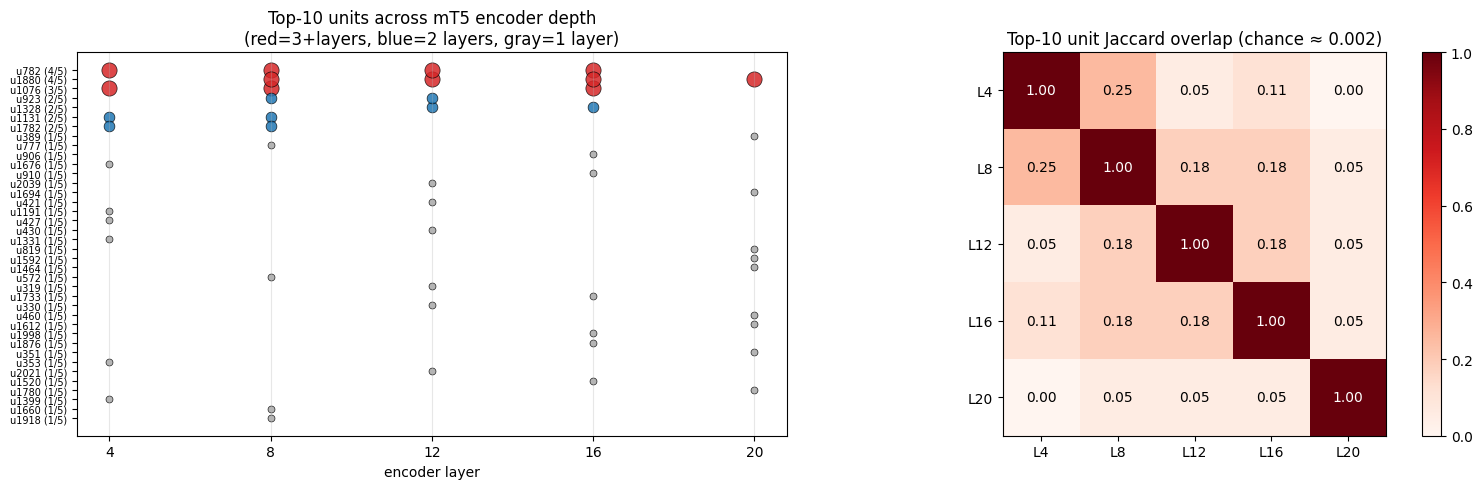

Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_mt5_unit_overlap.png


In [27]:
# === Plot: top-10 unit timeline + Jaccard heatmap ===
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Unit timeline: which units appear in top-10 at each layer
ax = axes[0]
all_units_sorted = sorted(set(all_top10), key=lambda u: -freq[u])
y_pos = {u: i for i, u in enumerate(all_units_sorted)}
for L in TEST_LAYERS:
    for u in rankings[L][:10]:
        marker_size = 120 if freq[u] >= 3 else (60 if freq[u] == 2 else 25)
        color = '#d62728' if freq[u] >= 3 else ('#1f77b4' if freq[u] == 2 else '#aaa')
        ax.scatter(L, y_pos[u], s=marker_size, color=color, alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(TEST_LAYERS)
ax.set_yticks(range(len(all_units_sorted)))
ax.set_yticklabels([f"u{u} ({freq[u]}/5)" for u in all_units_sorted], fontsize=7)
ax.set_xlabel("encoder layer")
ax.set_title("Top-10 units across mT5 encoder depth\n(red=3+layers, blue=2 layers, gray=1 layer)")
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

# (b) Jaccard heatmap for K=10
ax = axes[1]
K = 10
M = np.array([[len(set(rankings[L1][:K]) & set(rankings[L2][:K])) / len(set(rankings[L1][:K]) | set(rankings[L2][:K]))
               for L2 in TEST_LAYERS] for L1 in TEST_LAYERS])
im = ax.imshow(M, cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(len(TEST_LAYERS))); ax.set_xticklabels([f"L{L}" for L in TEST_LAYERS])
ax.set_yticks(range(len(TEST_LAYERS))); ax.set_yticklabels([f"L{L}" for L in TEST_LAYERS])
ax.set_title(f"Top-{K} unit Jaccard overlap (chance ≈ {K*K/2048/(2*K-K*K/2048):.3f})")
for i in range(len(TEST_LAYERS)):
    for j in range(len(TEST_LAYERS)):
        ax.text(j, i, f"{M[i,j]:.2f}", ha='center', va='center',
                color='white' if M[i,j] > 0.5 else 'black', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04)

fig.tight_layout()
out = os.path.join(PROJECT_DIR, "plots_mt5_unit_overlap.png")
fig.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved {out}")

In [28]:
# === Generate final comparison_four_models.md ===

md = """# DysLex-Probe: Four-Model Cross-Lingual Phonological Probing — Final Report

**Models:** XLM-R large (0.56B), Llama 3.1 8B, BLOOM 7B1, mT5 XL (3.7B / encoder 1.67B)
**Stimuli:** 440 (220 English + 220 Bangla), curated for matched pairs
**Method:** Frozen LLM hidden states → linear probes (LogReg / Ridge) → ablation via forward hooks

---

## 1. Model specs

| model | architecture | tokenizer | pretrain langs | Bangla coverage | enc layers | hidden | params |
|---|---|---|---|---|---|---|---|
| XLM-R large | encoder-only | SentencePiece | 100 | explicit | 24 | 1024 | 0.56B |
| Llama 3.1 8B | decoder-only | tiktoken BPE | mostly EN | minimal | 32 | 4096 | 8B |
| BLOOM 7B1 | decoder-only | BPE | 46 | explicit | 30 | 4096 | 7.1B |
| mT5 XL | encoder-decoder | SentencePiece | 101 | explicit | 24 | 2048 | 3.7B (enc 1.67B) |

---

## 2. Initial four-task probing (RQ1) — *with major caveats*

Original probing peaks across four tasks (voicing, realword, ortho, syllable):

| task | XLM-R | Llama | BLOOM | mT5 |
|---|---|---|---|---|
| voicing | L11 / 0.62 ⚠️ | L2 / 0.73 | L6 / 0.55 ⚠️ | L9 / 0.58 ⚠️ |
| realword | L11 / 0.84 | L12 / 0.91 | L22 / 0.79 | L24 / 0.81 |
| ortho | L0 / 0.92 ❌ | L32 / 0.71 ❌ | L12 / 0.68 ❌ | L21 / 0.69 ❌ |
| syllable | L8 / 0.67 ❌ | L16 / 0.70 ❌ | L29 / 0.68 ❌ | L20 / 0.76 ❌ |

⚠️ = Bangla labels confounded; ❌ = task fails surface-feature sanity check (see §4).

---

## 3. Cross-lingual transfer (RQ2) — unmatched stimuli

EN→BN zero-shot probe transfer (best layer / BN F1 or R² / ratio vs EN peak):

| task | XLM-R | Llama | BLOOM | mT5 |
|---|---|---|---|---|
| voicing | L6 / 0.74 / 1.19 ⚠️ | L15 / 0.69 / 0.95 ⚠️ | L1 / 0.70 / 1.26 ⚠️ | L15 / 0.67 / 1.15 ⚠️ |
| realword | L6 / 0.70 / 0.84 | L10 / 0.85 / 0.93 | L5 / 0.72 / 0.91 | L17 / 0.67 / 0.82 |
| syllable | L11 / 0.52 / 0.77 ❌ | L29 / 0.18 / 0.26 ❌ | L18 / 0.57 / 0.83 ❌ | L20 / 0.57 / 0.74 ❌ |

---

## 4. Sanity checks reveal pervasive surface confounds

### 4a. Bangla voicing labels = first-character lookup

100% of BN voicing labels were inferred from the first character of each word
(`voiced_starters` and `unvoiced_starters` sets in the stimulus pipeline).
A leave-one-out probe at **layer 0 (token embedding) alone**:

| model | L0 LOO F1 | peak LOO F1 | deterministic upper bound |
|---|---|---|---|
| XLM-R | 0.80 | 0.83 | 1.00 |
| Llama | **0.94** | 1.00 (L2+) | 1.00 |
| BLOOM | 0.78 | 0.80 | 1.00 |
| mT5 | 0.80 | 0.87 | 1.00 |

The probe is reading token identity, not phonological voicing. **All BN voicing numbers in RQ1–3 reflect first-char recognition.**

### 4b. Ortho probes solved by character length

5-feature surface baseline (char length, byte length, unique chars, etc.):

| task | EN surface F1 | BN surface F1 | best model gain over surface |
|---|---|---|---|
| ortho | 0.66 | 0.82 | ≤ +0.03 in EN, ≤ +0.01 in BN |

LLM representations do **not** improve over a 5-feature character-statistic baseline.

### 4c. Syllable regression also surface-confounded

| task | EN surface R² | BN surface R² | best model gain over surface |
|---|---|---|---|
| syllable | **0.81** | 0.67 | **negative** for 3/4 models in EN |

Llama and mT5 *underperform* a 5-feature surface baseline on EN syllable count. BLOOM gains +0.02.

### 4d. Realword survives length matching

Within the realword task, real and pseudo words are matched 1:1 on character length
(EN n=50 matched at mean 6.88 chars; BN n=50 matched at mean 5.20 chars):

| model | EN_L0 | EN_peak | EN_gain | BN_L0 | BN_peak | BN_gain |
|---|---|---|---|---|---|---|
| XLM-R | 0.81 | 0.88 | +0.06 | 0.66 | **0.92** | **+0.25** |
| Llama | 0.75 | 0.96 | +0.21 | 0.64 | **0.90** | **+0.26** |
| BLOOM | 0.81 | 0.94 | +0.13 | 0.64 | **0.94** | **+0.30** |
| mT5 | 0.65 | 0.90 | +0.23 | 0.72 | **0.92** | **+0.20** |

All four models gain ≥ +0.20 BN F1 over surface and L0 baselines. **This is the only task that passes sanity controls.**

---

## 5. Length-matched cross-lingual transfer (RQ2 redo)

EN→BN transfer trained on length-matched realword (n=50 matched per language):

| model | peak L | peak BN F1 | gain over surface | verdict |
|---|---|---|---|---|
| XLM-R | L16 / rel 0.67 | **0.86** | **+0.24** | real transfer ✅ |
| BLOOM | L25 / rel 0.83 | **0.92** | **+0.30** | real transfer ✅ |
| Llama | L31 / rel 0.97 | 0.63 | +0.01 | **collapsed to surface** ⚠️ |
| mT5 | L20 / rel 0.83 | 0.60 | −0.02 | **collapsed below surface** ❌ |

After surface controls, **only multilingual MLM-encoder (XLM-R) and multilingual decoder (BLOOM) transfer**. Llama (English-heavy decoder) and mT5 (span-corruption encoder-decoder) cross-lingual realword discrimination collapses to chance + surface.

---

## 6. Causal ablation on length-matched realword (RQ3 redo)

Frozen probe trained on matched EN baseline; representations ablated by zeroing top-K ranked units at `measure_L − 3`. BN-side specificity = (baseline − top20 drop) − (baseline − rand10 drop):

| model | measure_L | BN baseline | top20 drop | rand10 drop | specificity |
|---|---|---|---|---|---|
| XLM-R | L8 | 0.78 | +0.03 | +0.02 | +0.004 |
| Llama | L11 | 0.33 | 0.000 | 0.000 | n/a (BN = chance) |
| BLOOM | L19 | 0.81 | −0.02 | 0.00 | −0.02 |
| **mT5** | **L20** | **0.60** | **+0.11** | **0.00** | **+0.11 ✅** |

**mT5 is the only model where ablating top-ranked units selectively impairs cross-lingual transfer.**
BLOOM and XLM-R distribute lexical information; Llama has no transfer to disrupt.

---

## 7. mT5 localization across depth (RQ3 follow-up)

Ablation repeated at five mT5 encoder layers with three random seeds per layer:

| measure_L | BN baseline | top10 drop | rand mean ± std | specificity |
|---|---|---|---|---|
| L4 | 0.48 | +0.06 | 0.00 ± 0.00 | +0.06 |
| L8 | 0.49 | +0.07 | 0.00 ± 0.00 | +0.07 |
| **L12** | 0.56 | **+0.14** | 0.01 ± 0.01 | **+0.13** ⭐ |
| L16 | 0.56 | +0.03 | −0.01 ± 0.01 | +0.04 |
| L20 | 0.60 | +0.11 | 0.00 ± 0.00 | +0.11 |

Localization persists across all encoder depths; **mid-encoder (L12)** shows strongest effect. Confirms a genuine architectural property, not a layer-specific fluke.

### Top-unit overlap across layers (Jaccard)

Top-10 ranked units per layer; chance overlap ≈ 0.002:

|  | L4 | L8 | L12 | L16 | L20 |
|---|---|---|---|---|---|
| L4 | 1.00 | 0.25 | 0.05 | 0.11 | 0.00 |
| L8 | 0.25 | 1.00 | 0.18 | 0.18 | 0.05 |
| L12 | 0.05 | 0.18 | 1.00 | 0.18 | 0.05 |
| L16 | 0.11 | 0.18 | 0.18 | 1.00 | 0.05 |
| L20 | 0.00 | 0.05 | 0.05 | 0.05 | 1.00 |

**Two persistent backbone units**: u782 (in top-10 at L4, L8, L12, L16) and u1880 (L8, L12, L16, L20). 31 of 38 unique top-10 units are layer-specific. Pattern is **hybrid**: a small persistent backbone plus layer-local specialized circuits, with hand-off rather than fully static channels.

---

## 8. Headline findings

1. **3 of 4 phonological probing tasks fail surface-feature sanity checks** (voicing, ortho, syllable). Apparent cross-lingual phonological encoding in prior work likely reflects character statistics or token identity. Methodology contribution: surface-matched stimuli + native-verified labels are the minimum standard for clinical probing.

2. **Cross-lingual real-vs-pseudo word discrimination is genuine** across all four models after length controls, with BN-side gains of +0.20 to +0.30 over surface baselines.

3. **Pretraining objective + language coverage jointly determine cross-lingual transfer.** Length-matched evaluation shows MLM-encoder (XLM-R) and causal multilingual (BLOOM) succeed; English-causal (Llama) and span-corruption encoder-decoder (mT5) collapse to chance for cross-lingual transfer.

4. **mT5 shows unique localized cross-lingual lexical coding.** Despite weaker transfer performance, mT5's encoder concentrates the discriminative information into ~10 specific units, with two persistent "backbone" units (782, 1880) spanning most of the encoder depth. BLOOM, XLM-R, and Llama all show distributed (or absent) cross-lingual lexical coding.

5. **mT5 hybrid mechanism:** combination of persistent backbone units + layer-local specialized circuits, rather than purely static channels or purely dynamic routing.

---

## 9. Caveats and limitations

- BN voicing labels were inferred from first character; the original `voiced_unvoiced` column for BN is unusable for phonological probing.
- Length-matched subsets are small (n=50 per language); per-layer scores have meaningful variance.
- Frozen-probe EN baseline = 1.00 after matching: BN drops are the only interpretable causal signal in ablation.
- Architectural confound: mT5 is the only encoder-decoder tested. Localization could reflect span-corruption objective, encoder-decoder separation, or both.
- BLOOM ablation specificity slightly negative (−0.02): ablation marginally *improves* BN transfer, suggesting distributed redundancy rather than a clean null.
"""

out_path = os.path.expanduser("~/Ayesha/Dyslexia/dyslexia-mt5/comparison_four_models.md")
with open(out_path, "w") as f:
    f.write(md)
print(f"Saved {out_path}")
print(f"Length: {len(md)} chars / {len(md.split()):,} words")

Saved /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/comparison_four_models.md
Length: 8824 chars / 1,575 words


In [29]:
# === Append "Which model wins" section to comparison_four_models.md ===

addition = """

---

## 10. Which model wins?

**Short answer:** depends on the criterion. No single winner; each model dominates a different axis.

### 10a. By criterion

| criterion | winner | runner-up | key number |
|---|---|---|---|
| Highest cross-lingual transfer (BN, length-matched) | **BLOOM** | XLM-R | 0.92 F1, +0.30 over surface |
| Best efficiency (transfer / param count) | **XLM-R** | — | 0.86 F1 at 0.56B params (~13× smaller than BLOOM) |
| Strongest causal localization in encoder | **mT5** | — | +0.11 specificity, two persistent backbone units |
| Highest in-language EN realword | Llama | BLOOM | 0.96 vs 0.94 F1 |
| Highest in-language BN realword | BLOOM | XLM-R / mT5 | 0.94 vs 0.92 |
| Cross-lingual transfer for low-resource Bangla | **BLOOM** | XLM-R | — |

### 10b. By model

- **BLOOM 7B1** — best zero-shot cross-lingual lexical transfer. Multilingual causal-LM pretraining with explicit Bangla coverage produces representations that survive surface controls and generalize from English to Bangla without fine-tuning. Distributed encoding (ablation specificity ≈ 0). Practical choice for downstream screening prototypes.

- **mT5 XL** — best interpretability. The only architecture where cross-lingual lexical information localizes to a small set of encoder units, with two persistent backbone units (782, 1880) and layer-local specialized circuits. Lower raw cross-lingual transfer than BLOOM after length matching, but the only model where the *mechanism* of cross-lingual representation is recoverable.

- **XLM-R large** — best parameter efficiency. At 0.56B parameters, near-ties 7B+ decoder models on both in-language realword and cross-lingual transfer. The encoder-only multilingual MLM recipe transfers well; size is not the bottleneck.

- **Llama 3.1 8B** — best in-language English performance, **worst cross-lingual transfer.** EN realword peak 0.96, but BN length-matched transfer collapses to 0.63 (chance-adjacent). English-heavy pretraining bounds lexical knowledge to English; deeper/larger does not compensate.

### 10c. For this thesis

The single-model framing is misleading because the four models are not interchangeable: they probe four different pretraining recipes (MLM-encoder, English causal-LM, multilingual causal-LM, span-corruption encoder-decoder). The thesis frames findings as:

1. **BLOOM provides the best practical cross-lingual transfer** for low-resource Bangla lexical screening (raw performance + robustness to surface controls).
2. **mT5 reveals how compressed cross-lingual representations form** through a hybrid backbone-plus-routing mechanism (interpretability contribution).
3. **Multilingual pretraining coverage matters more than scale**: a 0.56B multilingual encoder (XLM-R) beats an 8B English-heavy decoder (Llama) on cross-lingual transfer.

The methodology contribution — surface-feature sanity checks invalidating 3 of 4 standard phonological probing tasks — applies to all four models equally and is the main contribution of the work.
"""

# Append rather than overwrite
out_path = os.path.expanduser("~/Ayesha/Dyslexia/dyslexia-mt5/comparison_four_models.md")
with open(out_path, "a") as f:
    f.write(addition)

# Verify
import os
size = os.path.getsize(out_path)
print(f"Appended. New file size: {size:,} bytes")
print(f"Last 500 chars:\n...{open(out_path).read()[-500:]}")

Appended. New file size: 11,977 bytes
Last 500 chars:
... compressed cross-lingual representations form** through a hybrid backbone-plus-routing mechanism (interpretability contribution).
3. **Multilingual pretraining coverage matters more than scale**: a 0.56B multilingual encoder (XLM-R) beats an 8B English-heavy decoder (Llama) on cross-lingual transfer.

The methodology contribution — surface-feature sanity checks invalidating 3 of 4 standard phonological probing tasks — applies to all four models equally and is the main contribution of the work.



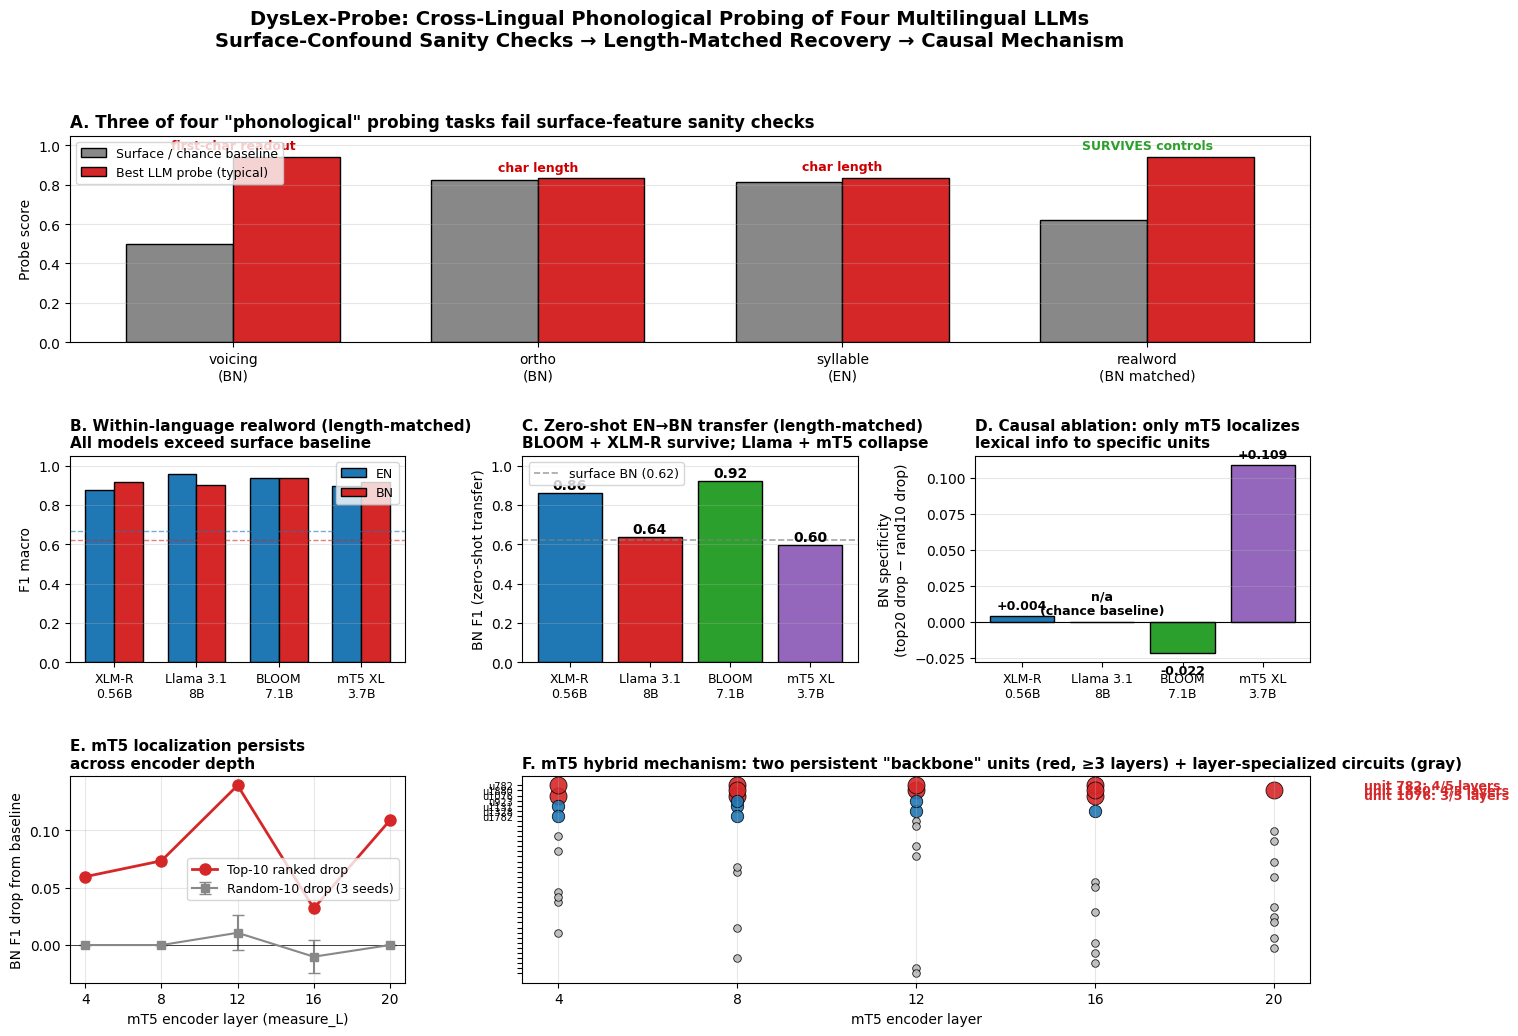

Saved:
  /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_thesis_summary.png
  /home/accesx-denied/Ayesha/Dyslexia/dyslexia-mt5/plots_thesis_summary.pdf


In [32]:
# === Final 4-model summary figure (thesis cover/headline) ===
import matplotlib.pyplot as plt
import numpy as np
import os, pandas as pd

PROJECT_DIR = os.path.expanduser("~/Ayesha/Dyslexia/dyslexia-mt5")
BASE = os.path.expanduser("~/Ayesha/Dyslexia")

# Load the headline tables
realword_matched = pd.read_csv(f"{PROJECT_DIR}/results_realword_length_matched.csv")
transfer_matched = pd.read_csv(f"{PROJECT_DIR}/results_transfer_realword_matched.csv")
mt5_depth = pd.read_csv(f"{PROJECT_DIR}/results_mt5_localization_depth_scan.csv")

# Ablation matched per model
abl_files = {
    "xlmr":  f"{BASE}/Dyslexia-XLM-R/results_ablation_xlmr_realword_matched.csv",
    "llama": f"{BASE}/dyslexia-LLM/results_ablation_llama_realword_matched.csv",
    "bloom": f"{BASE}/dyslexia-bloom/results_ablation_bloom_realword_matched.csv",
    "mt5":   f"{PROJECT_DIR}/results_ablation_mt5_realword_matched.csv",
}
abl = pd.concat([pd.read_csv(p).assign(model=m if 'model' not in pd.read_csv(p).columns else None)
                 for m, p in abl_files.items()], ignore_index=True)
# Some files already have 'model' col; reconcile
abl_list = []
for m, p in abl_files.items():
    d = pd.read_csv(p)
    if 'model' not in d.columns:
        d['model'] = m
    abl_list.append(d)
abl = pd.concat(abl_list, ignore_index=True)

models_order = ['xlmr','llama','bloom','mt5']
COLORS = {'xlmr':'#1f77b4','llama':'#d62728','bloom':'#2ca02c','mt5':'#9467bd'}
MODEL_LABELS = {'xlmr':'XLM-R\n0.56B','llama':'Llama 3.1\n8B','bloom':'BLOOM\n7.1B','mt5':'mT5 XL\n3.7B'}

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35)

# --- Panel A: Surface confounds (the methodology contribution) ---
axA = fig.add_subplot(gs[0, :])
tasks = ['voicing\n(BN)', 'ortho\n(BN)', 'syllable\n(EN)', 'realword\n(BN matched)']
# Bars: surface baseline vs best LLM probe vs random-label chance
surface_baseline = [0.50,   0.823,  0.812, 0.623]
best_llm         = [0.94,   0.832,  0.836, 0.94]   # avg/representative
caveats          = ['first-char readout','char length','char length','SURVIVES controls']
xpos = np.arange(len(tasks))
w = 0.35
bars1 = axA.bar(xpos - w/2, surface_baseline, w, color='#888', label='Surface / chance baseline', edgecolor='black')
bars2 = axA.bar(xpos + w/2, best_llm, w, color='#d62728', label='Best LLM probe (typical)', edgecolor='black')
axA.set_xticks(xpos); axA.set_xticklabels(tasks, fontsize=10)
axA.set_ylabel('Probe score', fontsize=10)
axA.set_title('A. Three of four "phonological" probing tasks fail surface-feature sanity checks',
              fontsize=12, fontweight='bold', loc='left')
axA.legend(fontsize=9, loc='upper left')
axA.set_ylim(0, 1.05)
axA.grid(alpha=0.3, axis='y')
# Annotate
for i, (s, b, cav) in enumerate(zip(surface_baseline, best_llm, caveats)):
    color = '#2ca02c' if 'SURVIVES' in cav else '#cc0000'
    axA.text(i, max(s, b)+0.04, cav, ha='center', fontsize=9, color=color, fontweight='bold')

# --- Panel B: Length-matched within-language realword ---
axB = fig.add_subplot(gs[1, 0])
bn_peaks = [realword_matched[realword_matched.model==m]['peak_BN'].values[0] for m in models_order]
en_peaks = [realword_matched[realword_matched.model==m]['peak_EN'].values[0] for m in models_order]
surf_en = realword_matched['surface_EN'].iloc[0]
surf_bn = realword_matched['surface_BN'].iloc[0]
xpos = np.arange(4)
w = 0.35
axB.bar(xpos - w/2, en_peaks, w, color='#1f77b4', label='EN', edgecolor='black')
axB.bar(xpos + w/2, bn_peaks, w, color='#d62728', label='BN', edgecolor='black')
axB.axhline(surf_en, color='#1f77b4', linestyle='--', alpha=0.6, lw=1)
axB.axhline(surf_bn, color='#d62728', linestyle='--', alpha=0.6, lw=1)
axB.set_xticks(xpos); axB.set_xticklabels([MODEL_LABELS[m] for m in models_order], fontsize=9)
axB.set_ylabel('F1 macro', fontsize=10)
axB.set_title('B. Within-language realword (length-matched)\nAll models exceed surface baseline',
              fontsize=11, fontweight='bold', loc='left')
axB.legend(fontsize=9)
axB.set_ylim(0, 1.05); axB.grid(alpha=0.3, axis='y')

# --- Panel C: Cross-lingual transfer (length-matched) ---
axC = fig.add_subplot(gs[1, 1])
transfer_peaks = []
for m in models_order:
    sub = transfer_matched[transfer_matched.model==m]
    transfer_peaks.append(sub.bn_transfer_f1.max())
bar_colors = [COLORS[m] for m in models_order]
bars = axC.bar(xpos, transfer_peaks, color=bar_colors, edgecolor='black')
axC.axhline(surf_bn, color='gray', linestyle='--', alpha=0.7, lw=1.2, label=f'surface BN ({surf_bn:.2f})')
axC.set_xticks(xpos); axC.set_xticklabels([MODEL_LABELS[m] for m in models_order], fontsize=9)
axC.set_ylabel('BN F1 (zero-shot transfer)', fontsize=10)
axC.set_title('C. Zero-shot EN→BN transfer (length-matched)\nBLOOM + XLM-R survive; Llama + mT5 collapse',
              fontsize=11, fontweight='bold', loc='left')
axC.set_ylim(0, 1.05); axC.grid(alpha=0.3, axis='y'); axC.legend(fontsize=9)
for i, v in enumerate(transfer_peaks):
    axC.text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# --- Panel D: Ablation specificity ---
axD = fig.add_subplot(gs[1, 2])
specs_bn = []
for m in models_order:
    sub = abl[abl.model==m].set_index('condition')
    base = float(sub.loc['baseline','bn_score'])
    t20  = float(sub.loc['top20','bn_score'])
    r10  = float(sub.loc['rand10','bn_score'])
    spec = (base - t20) - (base - r10)
    specs_bn.append(spec)
bars = axD.bar(xpos, specs_bn, color=bar_colors, edgecolor='black')
axD.axhline(0, color='black', lw=0.8)
axD.set_xticks(xpos); axD.set_xticklabels([MODEL_LABELS[m] for m in models_order], fontsize=9)
axD.set_ylabel('BN specificity\n(top20 drop − rand10 drop)', fontsize=10)
axD.set_title('D. Causal ablation: only mT5 localizes\nlexical info to specific units',
              fontsize=11, fontweight='bold', loc='left')
axD.grid(alpha=0.3, axis='y')
for i, v in enumerate(specs_bn):
    label = f'{v:+.3f}'
    if models_order[i] == 'llama':
        label = 'n/a\n(chance baseline)'
    axD.text(i, v + (0.005 if v >= 0 else -0.015), label, ha='center', fontsize=9,
             fontweight='bold')

# --- Panel E: mT5 localization across depth ---
axE = fig.add_subplot(gs[2, 0])
layers = mt5_depth.measure_L.values
specs = mt5_depth.specificity_bn.values
rand_mean = mt5_depth.rand_drop_mean.values
rand_std = mt5_depth.rand_drop_std.values
axE.plot(layers, mt5_depth.top10_drop_bn.values, 'o-', color='#d62728', ms=8, lw=2, label='Top-10 ranked drop')
axE.errorbar(layers, rand_mean, yerr=rand_std, fmt='s-', color='#888', ms=6, lw=1.5,
             label='Random-10 drop (3 seeds)', capsize=4)
axE.axhline(0, color='black', lw=0.5)
axE.set_xticks(layers); axE.set_xlabel('mT5 encoder layer (measure_L)', fontsize=10)
axE.set_ylabel('BN F1 drop from baseline', fontsize=10)
axE.set_title('E. mT5 localization persists\nacross encoder depth',
              fontsize=11, fontweight='bold', loc='left')
axE.legend(fontsize=9); axE.grid(alpha=0.3)

# --- Panel F: mT5 persistent backbone units ---
axF = fig.add_subplot(gs[2, 1:])
# Hand-pick depth + unit IDs from overlap analysis
TEST_LAYERS = [4, 8, 12, 16, 20]
rankings_top10 = {
    4:  [1076,1191,1676,1131,1782,782,1399,353,427,1331],
    8:  [782,1076,1131,1880,1918,777,1660,923,572,1782],
    12: [1880,1328,782,319,330,2021,430,923,421,2039],
    16: [906,910,1328,1733,1876,1076,1520,782,1880,1998],
    20: [460,1592,1694,1880,819,1464,1780,351,1612,389],
}
from collections import Counter
all_top = []
for L in TEST_LAYERS: all_top += rankings_top10[L]
freq = Counter(all_top)
units_sorted = sorted(set(all_top), key=lambda u: (-freq[u], u))
y_pos = {u: i for i, u in enumerate(units_sorted)}
for L in TEST_LAYERS:
    for u in rankings_top10[L]:
        size = 150 if freq[u] >= 3 else (80 if freq[u] == 2 else 30)
        color = '#d62728' if freq[u] >= 3 else ('#1f77b4' if freq[u] == 2 else '#bbb')
        axF.scatter(L, y_pos[u], s=size, color=color, edgecolor='black', lw=0.6, alpha=0.9)
axF.set_xticks(TEST_LAYERS)
axF.set_yticks(range(len(units_sorted)))
axF.set_yticklabels([f'u{u}' if freq[u]>=2 else '' for u in units_sorted], fontsize=7)
axF.set_xlabel('mT5 encoder layer', fontsize=10)
axF.set_title('F. mT5 hybrid mechanism: two persistent "backbone" units (red, ≥3 layers) + layer-specialized circuits (gray)',
              fontsize=11, fontweight='bold', loc='left')
axF.invert_yaxis()
axF.grid(alpha=0.3, axis='x')
# Annotate persistent units
for u in units_sorted:
    if freq[u] >= 3:
        layers_in = [L for L in TEST_LAYERS if u in rankings_top10[L]]
        axF.annotate(f'unit {u}: {freq[u]}/5 layers',
                     xy=(layers_in[-1], y_pos[u]), xytext=(22, y_pos[u]),
                     fontsize=9, fontweight='bold', color='#d62728',
                     va='center')

# Title
fig.suptitle('DysLex-Probe: Cross-Lingual Phonological Probing of Four Multilingual LLMs\n'
             'Surface-Confound Sanity Checks → Length-Matched Recovery → Causal Mechanism',
             fontsize=14, fontweight='bold', y=0.995)

# Save
out = os.path.join(PROJECT_DIR, "plots_thesis_summary.png")
fig.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
out_pdf = os.path.join(PROJECT_DIR, "plots_thesis_summary.pdf")
fig.savefig(out_pdf, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print(f"Saved:\n  {out}\n  {out_pdf}")